<a href="https://colab.research.google.com/github/CPernet/Semantically_Incongruent_or_Congruent_Eggplants_revised/blob/main/erps_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trial-level ERP analysis of sentence-final expectancy and semantic integration

The present reanalysis uses the N400Stimset dataset introduced by Toffolo et al. (2022), an auditory sentence-congruity ERP dataset designed to elicit semantic-integration responses to sentence-final words. In the original study, participants listened to spoken sentences with semantically congruent or incongruent endings, and the authors reported ERP effects in the Recognition Potential, N400, and LPC/P600 time ranges (Toffolo et al., 2022). The associated Dryad dataset provides the stimulus set and the high-density EEG/ERP resources used for the task, including preprocessed ERP derivative `.mat` files and corresponding trial-rejection information. :contentReference[oaicite:0]{index=0}

This notebook runs the ERP part of the Toffolo et al. (2022) N400Stimset reanalysis. The original study tested ERP responses to sentence-final congruent and incongruent words, with effects reported for the Recognition Potential (RP), N400, and Late Positive Component (LPC/P600). The present analysis keeps the sentence-final ERP focus and uses the predictor table created in the stimulus notebook to model retained ERP/EEG trials at the trial level.

This notebook belongs to the GitHub repository for the Toffolo et al. language reanalysis:  
[https://github.com/CPernet/Semantically_Incongruent_or_Congruent_Eggplants_revised](https://github.com/CPernet/Semantically_Incongruent_or_Congruent_Eggplants_revised)

The stimulus notebook created the GLM-ready table of item-level predictors. That table keeps `stim_key` as the stimulus identifier and contains predictors for each sentence-final target word, including human cloze probability, GPT-2 surprisal, LLM-derived expectancy, semantic similarity, lexical frequency, word length, phonology, syntactic complexity, and affective features.

This ERP notebook uses the processed N400Stimset ERP derivatives and epoched EEG files: subject-level ERP `.mat` files, paired `*_trialrej.tsv` files, subject event information, and EEGLAB epoch files for the CP, GA, LD, Order, and Time analysis schemes. These files contain the retained trials after preprocessing and rejection.

The notebook runs three scripts. `erp_analysis/export_erp_long.py` creates `ALL_subjects_ALL_erp_trial_lookup.tsv`, a retained-trial lookup that records the subject, analysis scheme, condition, retained-trial number, EEGLAB event information, original event row, stimulus file, and `stim_key` for every retained ERP trial. `eeg_analysis/prepare_limo_design_matrix.py` uses that lookup to create subject-specific GLM design matrices by attaching the stimulus predictors through `stim_key`. `eeg_analysis/run_limo_first_level_glm.py` pairs each subject’s epoched EEG file with the matching design matrix and estimates beta and t values for the selected predictors across channels and timepoints.

The outputs of this notebook are the retained-trial lookup, the subject-specific GLM design matrices, and the first-level EEG/ERP GLM results. These outputs test whether sentence-final expectancy, surprisal, semantic fit, lexical properties, phonological structure, syntactic complexity, and affective tone explain variation in RP, N400/PN400, and LPC/P600 activity.

In [10]:
%cd /content

!rm -rf Semantically_Incongruent_or_Congruent_Eggplants_revised
!git clone https://github.com/CPernet/Semantically_Incongruent_or_Congruent_Eggplants_revised.git

%cd /content/Semantically_Incongruent_or_Congruent_Eggplants_revised

/content
Cloning into 'Semantically_Incongruent_or_Congruent_Eggplants_revised'...
remote: Enumerating objects: 475, done.
remote: Counting objects: 100% (195/195), done.
remote: Compressing objects: 100% (154/154), done.
remote: Total 475 (delta 128), reused 73 (delta 41), pack-reused 280 (from 1)
Receiving objects: 100% (475/475), 100.95 MiB | 17.60 MiB/s, done.
Resolving deltas: 100% (276/276), done.
/content/Semantically_Incongruent_or_Congruent_Eggplants_revised


In [11]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 12.1 MB/s eta 0:00:00


In [12]:
!unzip language_outputs.zip

Archive:  language_outputs.zip
   creating: language_outputs/
  inflating: language_outputs/ALL_language_metrics.tsv  
  inflating: language_outputs/ALL_predictor_diagnostics_vif.tsv  
  inflating: language_outputs/ALL_predictor_diagnostics_correlations.tsv  
  inflating: language_outputs/ALL_language_metrics_GLM.tsv  


**Note**: Due to their size, the N400 ERP derivatives are stored on Google Drive and mounted during notebook execution.

In [13]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -o erps.zip

Archive:  erps.zip
  inflating: erps/task-N400Stimset_erp-CP_trialrej.json  
  inflating: erps/task-N400Stimset_erp-GA_filter.json  
  inflating: erps/task-N400Stimset_erp-GA_trialrej.json  
  inflating: erps/task-N400Stimset_erp-LD_trialrej.json  
  inflating: erps/task-N400Stimset_erp-Order_trialrej.json  
  inflating: erps/task-N400Stimset_erp-Time_trialrej.json  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-CP.mat  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-CP_trialrej.tsv  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-GA.mat  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-GA_trialrej.tsv  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-LD.mat  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-LD_trialrej.tsv  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-Order.mat  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-Order_trialrej.tsv  
  inflating: erps/sub-01/sub-01_task-N400Stimset_erp-Time.mat  
  inflating: erps/sub-01/sub

In [14]:
%cd /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/

/content/Semantically_Incongruent_or_Congruent_Eggplants_revised


# Export retained ERP trials

This section creates the retained-trial lookup used to connect the ERP data with the stimulus predictors.

The export script reads the ERP `.mat` files, the matching `*_trialrej.tsv` files, the subject event information, and the stimulus lookup. It runs across the CP, GA, LD, Order, and Time analysis schemes.

The output is:

`ALL_subjects_ALL_erp_trial_lookup.tsv`

For each retained ERP trial, the table stores the subject, analysis scheme, condition, retained-trial number, event information, stimulus file, and `stim_key`.

In [ ]:
!python erp_analysis/export_erp_long.py \
  "/content/drive/MyDrive/N400/erps" \
  --analyses ALL \
  --subjects ALL \
  --language-metrics "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv" \
  --output-dir "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/eeg_outputs"

Loaded 442 stimulus mappings from /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv
Found 104 ERP MAT files.
Using ERP root: /content/drive/MyDrive/N400/erps
Analyses: CP, GA, LD, Order, Time
Subjects: ALL
Language metrics: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv
Combined lookup: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv

Processing sub-01_task-N400Stimset_erp-CP.mat
  Using sub-01_task-N400Stimset_erp-CP_trialrej.tsv
  Condition 1: Congruent: Cloze Probability ≥ 96 % - 54 before rejection, 29 reported retained, 29 MAT retained
  Condition 2: Congruent: 96 % > Cloze Probability ≥ 90 % - 56 before rejection, 40 reported retained, 40 MAT retained
  Condition 3: Congruent: 90 % > Cloze Probability ≥ 80 % - 47 before rejection, 30 reported retained, 30 MAT retained
  Condition 4: Congruent: Cloze

In [15]:
#%cd /content/Semantically_Incongruent_or_Congruent_Eggplants_revised
#!zip -r "/content/eeg_outputs.zip" "eeg_outputs"

/content/Semantically_Incongruent_or_Congruent_Eggplants_revised
	zip warning: name not matched: eeg_outputs

zip error: Nothing to do! (try: zip -r /content/eeg_outputs.zip . -i eeg_outputs)


In [ ]:
#from google.colab import files
#files.download("/content/eeg_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
!unzip -o eeg_outputs.zip -d /content/Semantically_Incongruent_or_Congruent_Eggplants_revised

Archive:  eeg_outputs.zip
   creating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/eeg_outputs/
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup_export_log.tsv  
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv  


In [ ]:
!python erp_analysis/export_erp_long.py \
  "/content/drive/MyDrive/N400/erps" \
  --analyses ALL \
  --subjects ALL \
  --language-metrics "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv" \
  --output-dir "/content/drive/MyDrive/N400/eeg_outputs"

Loaded 442 stimulus mappings from /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv
Found 104 ERP MAT files.
Using ERP root: /content/drive/MyDrive/N400/erps
Analyses: CP, GA, LD, Order, Time
Subjects: ALL
Language metrics: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv
Combined lookup: /content/drive/MyDrive/N400/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv

Processing sub-01_task-N400Stimset_erp-CP.mat
  Using sub-01_task-N400Stimset_erp-CP_trialrej.tsv
  Condition 1: Congruent: Cloze Probability ≥ 96 % - 54 before rejection, 29 reported retained, 29 MAT retained
  Condition 2: Congruent: 96 % > Cloze Probability ≥ 90 % - 56 before rejection, 40 reported retained, 40 MAT retained
  Condition 3: Congruent: 90 % > Cloze Probability ≥ 80 % - 47 before rejection, 30 reported retained, 30 MAT retained
  Condition 4: Congruent: Cloze Probability < 80 % - 43 before rejec

In [ ]:
!python erp_analysis/export_erp_long.py \
  "/content/drive/MyDrive/N400/erps" \
  --analyses ALL \
  --subjects ALL \
  --language-metrics "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv" \
  --output-dir "/content/drive/MyDrive/N400/eeg_outputs"

Loaded 442 stimulus mappings from /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv
Found 104 ERP MAT files.
Using ERP root: /content/drive/MyDrive/N400/erps
Analyses: CP, GA, LD, Order, Time
Subjects: ALL
Language metrics: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics.tsv
Combined lookup: /content/drive/MyDrive/N400/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv

Processing sub-01_task-N400Stimset_erp-CP.mat
  Using sub-01_task-N400Stimset_erp-CP_trialrej.tsv
  Condition 1: Congruent: Cloze Probability ≥ 96 % - 54 before rejection, 29 reported retained, 29 MAT retained
  Condition 2: Congruent: 96 % > Cloze Probability ≥ 90 % - 56 before rejection, 40 reported retained, 40 MAT retained
  Condition 3: Congruent: 90 % > Cloze Probability ≥ 80 % - 47 before rejection, 30 reported retained, 30 MAT retained
  Condition 4: Congruent: Cloze Probability < 80 % - 43 before rejec

term,meaning
Condition retention %,Percentage of trials retained after artifact rejection for one exported condition.
Condition imbalance,"Difference between the highest and lowest condition retention percentage within the same subject, analysis, and source file."
Difference from analysis mean,How far each condition's retention is above or below the average retention of its own analysis.


subject,analysis,plot_label,condition_label,retained_trial,stimulus_row,stim_key,trial_type
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,1,17,sound17,NPI
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,2,23,sound23,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,3,133,sound133,NPI
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,4,164,sound164,NPI
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,5,215,sound215,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,6,345,sound345,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,7,351,sound351,NPI
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,8,357,sound357,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,9,381,sound381,NPC
sub-01,CP,CP C1,Congruent: Cloze Probability ≥ 96 %,10,414,sound414,NPC


plot_label,condition_label
CP C1,Congruent: Cloze Probability ≥ 96 %
CP C2,Congruent: 96 % > Cloze Probability ≥ 90 %
CP C3,Congruent: 90 % > Cloze Probability ≥ 80 %
CP C4,Congruent: Cloze Probability < 80 %
CP C5,Incongruent: Cloze Probability ≥ 96 %
CP C6,Incongruent: 96 % > Cloze Probability ≥ 90 %
CP C7,Incongruent: 90 % > Cloze Probability ≥ 80 %
CP C8,Incongruent: Cloze Probability < 80 %
GA C1,Congruent
GA C2,Incongruent


plot_label,mean_pct,sd_pct,min_pct,max_pct,diff_from_analysis_mean_pp
CP C1,84.81,15.99,40.74,98.15,-0.79
CP C2,85.98,13.50,48.21,98.21,0.38
CP C3,85.21,14.42,53.19,97.87,-0.39
CP C4,84.53,17.63,32.56,100.00,-1.07
CP C5,86.64,16.82,34.55,100.00,1.04
CP C6,86.70,12.69,55.36,98.21,1.10
CP C7,83.94,16.06,40.43,95.74,-1.66
CP C8,87.02,14.11,54.76,100.00,1.42
GA C1,83.39,17.85,34.09,99.00,-0.21
GA C2,83.81,17.76,35.91,97.27,0.21


analysis,mean_imbalance_pp,sd_imbalance_pp,min_imbalance_pp,max_imbalance_pp
CP,13.15,6.21,4.73,26.37
GA,3.06,2.72,0.00,9.00
LD,7.38,3.54,1.91,14.79
Order,8.10,6.21,1.88,28.28
Time,17.71,12.37,5.46,53.53


statistic,value
Retained ERP-trial rows,35751.00
Subjects represented,24.00
Analyses represented,5.00
ERP MAT files represented,104.00
Unique stimulus keys,442.00
Unique stimulus files,442.00
Missing stim_key,0.00
Missing stim_file,0.00
Stimulus row minimum,1.00
Stimulus row maximum,442.00


analysis,congruence_group,mean_pct,sd_pct,min_pct,max_pct
CP,Congruent,85.14,15.18,32.56,100.00
CP,Incongruent,86.07,14.77,34.55,100.00
GA,Congruent,83.39,17.85,34.09,99.00
GA,Incongruent,83.81,17.76,35.91,97.27
LD,Congruent,85.87,15.28,42.03,100.00
LD,Incongruent,86.97,14.43,46.56,100.00
Order,Incongruent,86.54,14.90,42.42,101.02
Time,Congruent,86.06,16.27,25.00,101.96
Time,Incongruent,87.04,15.69,28.57,102.04


congruence_group,analysis,congruent_minus_incongruent_pp
,CP,-0.93
,GA,-0.42
,LD,-1.10
,Order,NaN
,Time,-0.98


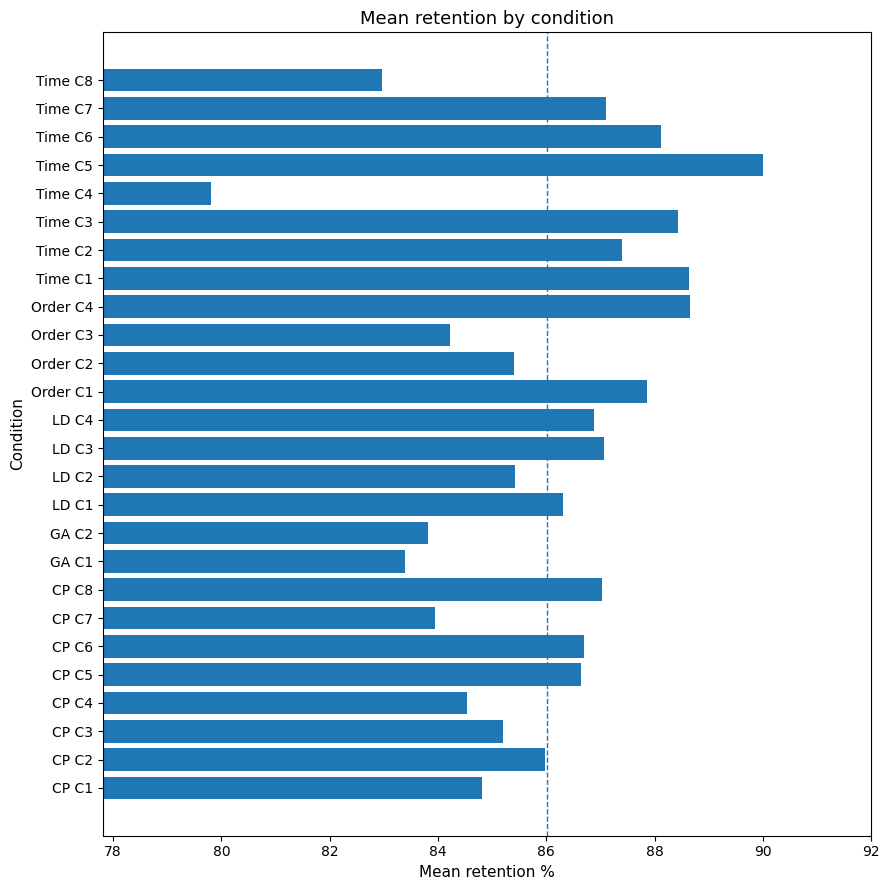

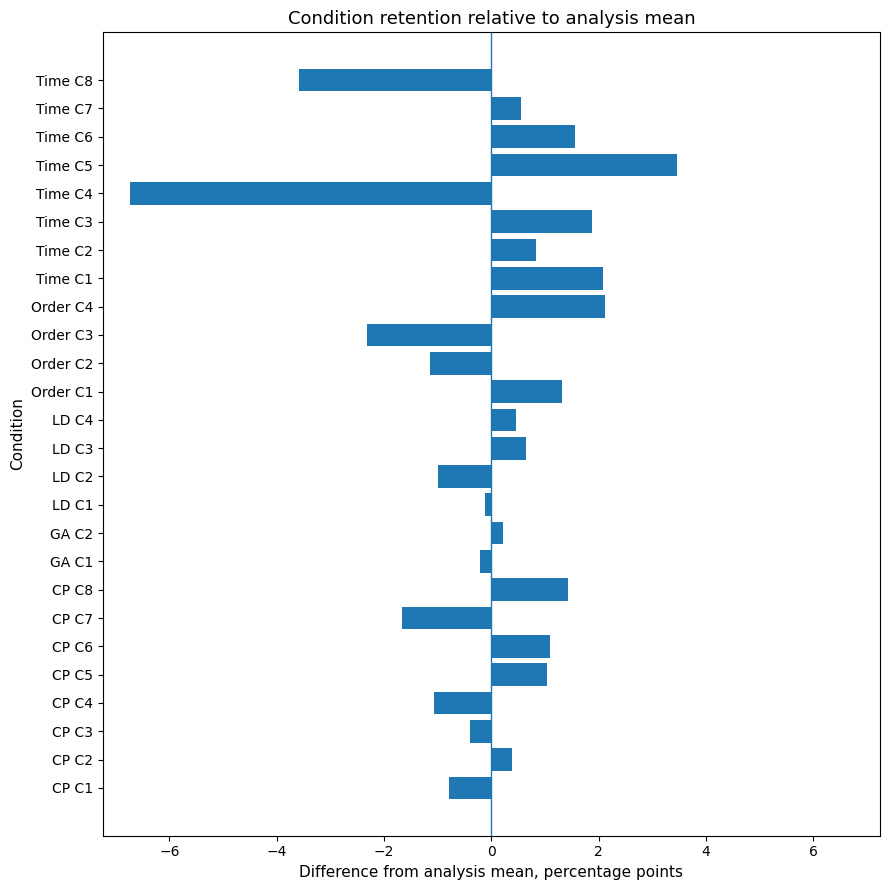

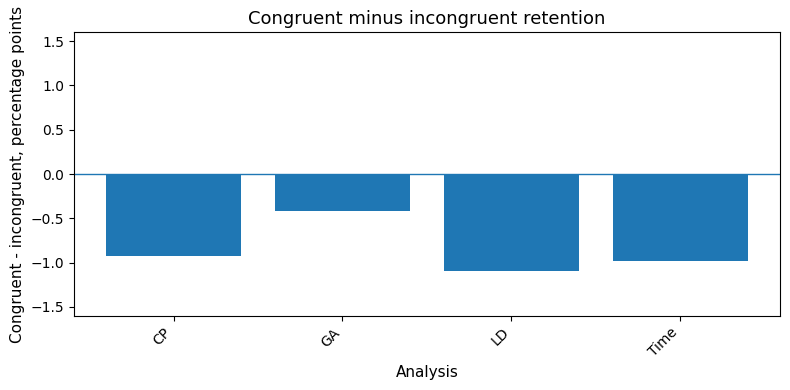

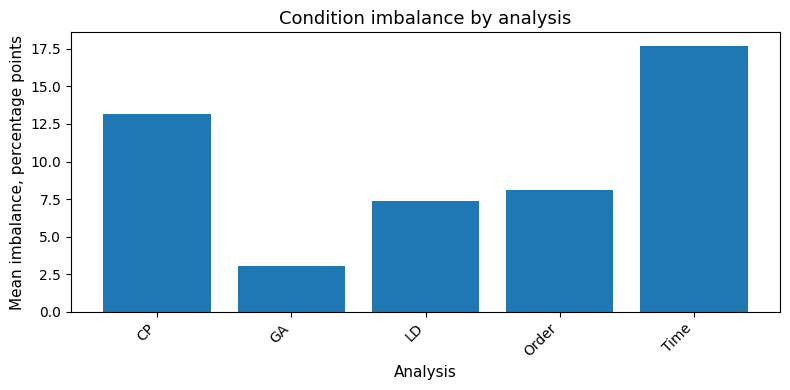

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# ============================================================
# Input
# ============================================================

lookup_path = "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv"
lookup = pd.read_csv(lookup_path, sep="\t")

# ============================================================
# Plot text sizes
# ============================================================

plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# ============================================================
# Display helper
# ============================================================

def show_table(df, title=None, max_height="420px"):
    if title is not None:
        display(HTML(f"""
        <h3 style="
            margin-top: 18px;
            margin-bottom: 8px;
            font-weight: bold;
        ">
            {title}
        </h3>
        """))

    html = df.to_html(index=False, escape=False)

    display(HTML(f"""
    <div style="
        max-height: {max_height};
        overflow-y: auto;
        overflow-x: auto;
        border: 1px solid #999999;
        padding: 8px;
        font-size: 13px;
        margin-bottom: 18px;
    ">
        <style>
            table {{
                border-collapse: collapse;
                width: 100%;
            }}

            th {{
                border: 1px solid #777777;
                padding: 7px;
                text-align: left;
                vertical-align: top;
                white-space: normal;
                word-wrap: break-word;
                max-width: 280px;
                background-color: #222222 !important;
                color: #ffffff !important;
                position: sticky;
                top: 0;
                z-index: 2;
                font-weight: bold;
            }}

            td {{
                border: 1px solid #dddddd;
                padding: 6px;
                text-align: left;
                vertical-align: top;
                white-space: normal;
                word-wrap: break-word;
                max-width: 280px;
            }}
        </style>
        {html}
    </div>
    """))

display(HTML("""
<h2 style="font-weight: bold; margin-bottom: 16px;">
ERP lookup export: first rows and statistical QC
</h2>
"""))

# ============================================================
# Build condition-level dataset
# ============================================================

condition_cells = (
    lookup[
        [
            "subject",
            "analysis",
            "source_file",
            "condition",
            "condition_label",
            "before_trial_rejection",
            "after_trial_rejection_mat",
        ]
    ]
    .drop_duplicates()
    .copy()
)

condition_cells["retention_pct"] = (
    condition_cells["after_trial_rejection_mat"]
    / condition_cells["before_trial_rejection"]
    * 100
)

condition_cells["plot_label"] = (
    condition_cells["analysis"].astype(str)
    + " C"
    + condition_cells["condition"].astype(str)
)

def get_congruence_group(label):
    label = str(label).lower()

    if "incongruent" in label or "inongruent" in label:
        return "Incongruent"

    if "congruent" in label:
        return "Congruent"

    return "Other"

condition_cells["congruence_group"] = condition_cells["condition_label"].apply(
    get_congruence_group
)

# ============================================================
# QC meaning table
# ============================================================

meaning_table = pd.DataFrame(
    {
        "term": [
            "Condition retention %",
            "Condition imbalance",
            "Difference from analysis mean",
        ],
        "meaning": [
            "Percentage of trials retained after artifact rejection for one exported condition.",
            "Difference between the highest and lowest condition retention percentage within the same subject, analysis, and source file.",
            "How far each condition's retention is above or below the average retention of its own analysis.",
        ],
    }
)

show_table(
    meaning_table,
    "QC term meanings",
)

# ============================================================
# 1. First rows of exported lookup
# ============================================================

first_rows = lookup[
    [
        "subject",
        "analysis",
        "condition",
        "condition_label",
        "retained_trial",
        "stimulus_row",
        "stim_key",
        "trial_type",
    ]
].head(15).copy()

first_rows["plot_label"] = (
    first_rows["analysis"].astype(str)
    + " C"
    + first_rows["condition"].astype(str)
)

first_rows = first_rows[
    [
        "subject",
        "analysis",
        "plot_label",
        "condition_label",
        "retained_trial",
        "stimulus_row",
        "stim_key",
        "trial_type",
    ]
]

show_table(
    first_rows,
    "1. First rows of exported lookup",
)

# ============================================================
# 2. Condition-label key for plot labels
# ============================================================

condition_key = (
    lookup[
        [
            "analysis",
            "condition",
            "condition_label",
        ]
    ]
    .drop_duplicates()
    .sort_values(["analysis", "condition"])
    .reset_index(drop=True)
)

condition_key["plot_label"] = (
    condition_key["analysis"].astype(str)
    + " C"
    + condition_key["condition"].astype(str)
)

condition_key = condition_key[
    [
        "plot_label",
        "condition_label",
    ]
]

show_table(
    condition_key,
    "2. Condition-label key for plot labels",
)

# ============================================================
# 3. Retention statistics by condition
# ============================================================

condition_stats = (
    condition_cells
    .groupby(["analysis", "condition", "plot_label"])["retention_pct"]
    .agg(
        mean_pct="mean",
        sd_pct="std",
        min_pct="min",
        max_pct="max",
    )
    .reset_index()
    .sort_values(["analysis", "condition"])
)

for col in ["mean_pct", "sd_pct", "min_pct", "max_pct"]:
    condition_stats[col] = condition_stats[col].round(2)

analysis_mean_retention = (
    condition_cells
    .groupby("analysis")["retention_pct"]
    .mean()
    .reset_index(name="analysis_mean_pct")
)

condition_stats = condition_stats.merge(
    analysis_mean_retention,
    on="analysis",
    how="left",
)

condition_stats["diff_from_analysis_mean_pp"] = (
    condition_stats["mean_pct"]
    - condition_stats["analysis_mean_pct"]
).round(2)

condition_stats_compact = condition_stats[
    [
        "plot_label",
        "mean_pct",
        "sd_pct",
        "min_pct",
        "max_pct",
        "diff_from_analysis_mean_pp",
    ]
]

show_table(
    condition_stats_compact,
    "3. Retention statistics by condition",
)

# ============================================================
# 4. Condition imbalance statistics by analysis
# ============================================================

condition_imbalance_by_file_analysis = (
    condition_cells
    .groupby(["subject", "analysis", "source_file"])["retention_pct"]
    .agg(
        min_retention_pct="min",
        max_retention_pct="max",
    )
    .reset_index()
)

condition_imbalance_by_file_analysis["condition_imbalance_pp"] = (
    condition_imbalance_by_file_analysis["max_retention_pct"]
    - condition_imbalance_by_file_analysis["min_retention_pct"]
)

imbalance_stats = (
    condition_imbalance_by_file_analysis
    .groupby("analysis")["condition_imbalance_pp"]
    .agg(
        mean_imbalance_pp="mean",
        sd_imbalance_pp="std",
        min_imbalance_pp="min",
        max_imbalance_pp="max",
    )
    .reset_index()
    .sort_values("analysis")
)

for col in [
    "mean_imbalance_pp",
    "sd_imbalance_pp",
    "min_imbalance_pp",
    "max_imbalance_pp",
]:
    imbalance_stats[col] = imbalance_stats[col].round(2)

show_table(
    imbalance_stats,
    "4. Condition imbalance statistics by analysis",
)

# ============================================================
# 5. Overall statistical QC summary
# ============================================================

overall_summary = pd.DataFrame(
    {
        "statistic": [
            "Retained ERP-trial rows",
            "Subjects represented",
            "Analyses represented",
            "ERP MAT files represented",
            "Unique stimulus keys",
            "Unique stimulus files",
            "Missing stim_key",
            "Missing stim_file",
            "Stimulus row minimum",
            "Stimulus row maximum",
            "Mean condition retention %",
            "SD condition retention %",
            "Minimum condition retention %",
            "Maximum condition retention %",
            "Mean condition imbalance, percentage points",
            "Maximum condition imbalance, percentage points",
        ],
        "value": [
            len(lookup),
            lookup["subject"].nunique(),
            lookup["analysis"].nunique(),
            lookup["source_file"].nunique(),
            lookup["stim_key"].nunique(),
            lookup["stim_file"].nunique(),
            int(lookup["stim_key"].isna().sum()),
            int(lookup["stim_file"].isna().sum()),
            int(lookup["stimulus_row"].min()),
            int(lookup["stimulus_row"].max()),
            round(condition_cells["retention_pct"].mean(), 2),
            round(condition_cells["retention_pct"].std(), 2),
            round(condition_cells["retention_pct"].min(), 2),
            round(condition_cells["retention_pct"].max(), 2),
            round(condition_imbalance_by_file_analysis["condition_imbalance_pp"].mean(), 2),
            round(condition_imbalance_by_file_analysis["condition_imbalance_pp"].max(), 2),
        ],
    }
)

show_table(
    overall_summary,
    "5. Overall statistical QC summary",
)

# ============================================================
# 6. Congruent vs incongruent retention statistics
# ============================================================

congruence_stats = (
    condition_cells[
        condition_cells["congruence_group"].isin(["Congruent", "Incongruent"])
    ]
    .groupby(["analysis", "congruence_group"])["retention_pct"]
    .agg(
        mean_pct="mean",
        sd_pct="std",
        min_pct="min",
        max_pct="max",
    )
    .reset_index()
    .sort_values(["analysis", "congruence_group"])
)

for col in ["mean_pct", "sd_pct", "min_pct", "max_pct"]:
    congruence_stats[col] = congruence_stats[col].round(2)

show_table(
    congruence_stats,
    "6. Congruent vs incongruent retention statistics",
)

congruence_pivot = (
    congruence_stats
    .pivot(
        index="analysis",
        columns="congruence_group",
        values="mean_pct",
    )
    .sort_index()
)

if "Congruent" in congruence_pivot.columns and "Incongruent" in congruence_pivot.columns:
    congruence_pivot["congruent_minus_incongruent_pp"] = (
        congruence_pivot["Congruent"]
        - congruence_pivot["Incongruent"]
    )
else:
    congruence_pivot["congruent_minus_incongruent_pp"] = np.nan

congruence_difference_table = (
    congruence_pivot[["congruent_minus_incongruent_pp"]]
    .reset_index()
)

congruence_difference_table["congruent_minus_incongruent_pp"] = (
    congruence_difference_table["congruent_minus_incongruent_pp"].round(2)
)

show_table(
    congruence_difference_table,
    "7. Congruent minus incongruent retention difference",
)

# ============================================================
# 7. Plots
# ============================================================

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
Plots
</h3>
"""))

# ------------------------------------------------------------
# Plot 1. Mean retention by condition
# ------------------------------------------------------------

condition_plot = condition_stats.copy().sort_values(["analysis", "condition"])

x_min = max(0, condition_plot["mean_pct"].min() - 2)
x_max = min(100, condition_plot["mean_pct"].max() + 2)

plt.figure(figsize=(9, 9))
plt.barh(
    condition_plot["plot_label"],
    condition_plot["mean_pct"],
)
plt.xlim(x_min, x_max)
plt.axvline(
    condition_plot["mean_pct"].mean(),
    linestyle="--",
    linewidth=1,
)
plt.xlabel("Mean retention %")
plt.ylabel("Condition")
plt.title("Mean retention by condition")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 2. Difference from analysis mean
# ------------------------------------------------------------

diff_plot = condition_stats.copy().sort_values(["analysis", "condition"])

max_abs_diff = abs(diff_plot["diff_from_analysis_mean_pp"]).max()
if pd.isna(max_abs_diff) or max_abs_diff == 0:
    max_abs_diff = 1

plt.figure(figsize=(9, 9))
plt.barh(
    diff_plot["plot_label"],
    diff_plot["diff_from_analysis_mean_pp"],
)
plt.axvline(0, linewidth=1)
plt.xlim(-max_abs_diff - 0.5, max_abs_diff + 0.5)
plt.xlabel("Difference from analysis mean, percentage points")
plt.ylabel("Condition")
plt.title("Condition retention relative to analysis mean")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Plot 3. Congruent minus incongruent retention
# ------------------------------------------------------------

congruence_diff_plot = (
    congruence_difference_table
    .dropna()
    .copy()
)

if len(congruence_diff_plot) > 0:
    max_abs_cong = abs(
        congruence_diff_plot["congruent_minus_incongruent_pp"]
    ).max()

    if pd.isna(max_abs_cong) or max_abs_cong == 0:
        max_abs_cong = 1

    plt.figure(figsize=(8, 4))
    plt.bar(
        congruence_diff_plot["analysis"],
        congruence_diff_plot["congruent_minus_incongruent_pp"],
    )
    plt.axhline(0, linewidth=1)
    plt.ylim(-max_abs_cong - 0.5, max_abs_cong + 0.5)
    plt.xlabel("Analysis")
    plt.ylabel("Congruent - incongruent, percentage points")
    plt.title("Congruent minus incongruent retention")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# Plot 4. Condition imbalance by analysis
# ------------------------------------------------------------

plt.figure(figsize=(8, 4))
plt.bar(
    imbalance_stats["analysis"],
    imbalance_stats["mean_imbalance_pp"],
)
plt.xlabel("Analysis")
plt.ylabel("Mean imbalance, percentage points")
plt.title("Condition imbalance by analysis")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Build subject-specific GLM design matrices

This section creates the design matrices used in the first-level ERP/EEG GLM.

The script combines the retained-trial lookup with the GLM-ready stimulus predictor table using `stim_key`. Each output design matrix contains the retained trials for one subject and one ERP analysis scheme, with the corresponding language predictors attached to each epoch.

In [ ]:
import pandas as pd

trial_lookup = "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/eeg_outputs/ALL_subjects_ALL_erp_trial_lookup.tsv"
predictors = "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/language_outputs/ALL_language_metrics_GLM.tsv"
output_dir = "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices"

lookup = pd.read_csv(trial_lookup, sep="\t")

analyses = (
    lookup["analysis"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Analyses found:", analyses)

for analysis in analyses:
    subjects = (
        lookup.loc[lookup["analysis"].eq(analysis), "subject"]
        .dropna()
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    subjects_arg = ",".join(subjects)

    print("\n========================================")
    print("Running analysis:", analysis)
    print("Subjects:", subjects_arg)
    print("Number of subjects:", len(subjects))
    print("========================================")

    !python erp_analysis/prepare_limo_design_matrix.py \
      --trial-lookup "{trial_lookup}" \
      --predictors "{predictors}" \
      --analysis "{analysis}" \
      --subjects "{subjects_arg}" \
      --output-dir "{output_dir}"

Analyses found: ['CP', 'GA', 'LD', 'Order', 'Time']

Running analysis: CP
Subjects: sub-01,sub-02,sub-03,sub-04,sub-06,sub-07,sub-08,sub-09,sub-11,sub-12,sub-13,sub-14,sub-16,sub-17,sub-19,sub-20,sub-21,sub-22,sub-23,sub-24
Number of subjects: 20

Design-matrix validation
------------------------
Subject: sub-01
Analysis: CP
Rows: 237
Unique stimuli: 214
Predictor columns: 19
Rows with any missing predictor value: 0
Saved design matrix: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-01_erp-CP_design_matrix.tsv

Design-matrix validation
------------------------
Subject: sub-02
Analysis: CP
Rows: 375
Unique stimuli: 213
Predictor columns: 19
Rows with any missing predictor value: 0
Saved design matrix: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-02_erp-CP_design_matrix.tsv

Design-matrix validation
------------------------
Subject: sub-03
Analysis: CP
Rows: 182
Unique stimuli: 140
Predictor columns: 

predictor,construct
target_dur(s),Target stimulus duration.
human_cp,Human cloze probability; target predictability based on human responses.
n_words_sentence,Sentence length.
target_n_letters,Orthographic length of the target word.
target_zipf_frequency,Lexical frequency of the target word on the Zipf scale.
target_n_phonemes,Phonological length of the target word.
target_valence,Affective valence of the target word.
target_arousal,Affective arousal associated with the target word.
target_dominance,Affective dominance/control rating associated with the target word.
llm_cp,Model-estimated cloze probability; computational predictability of the target.


condition_plot_label,condition_label
CP C1,Congruent: Cloze Probability ≥ 96 %
CP C2,Congruent: 96 % > Cloze Probability ≥ 90 %
CP C3,Congruent: 90 % > Cloze Probability ≥ 80 %
CP C4,Congruent: Cloze Probability < 80 %
CP C5,Incongruent: Cloze Probability ≥ 96 %
CP C6,Incongruent: 96 % > Cloze Probability ≥ 90 %
CP C7,Incongruent: 90 % > Cloze Probability ≥ 80 %
CP C8,Incongruent: Cloze Probability < 80 %
GA C1,Congruent
GA C2,Incongruent


subject,analysis,condition_plot_label,condition_label,eeg_trial,stim_key,trial_type,human_cp,llm_cp,context_target_similarity,target_surprisal_bits,sentence_mean_surprisal,sentence_perplexity,syntax_mean_dependency_distance,context_shift_index
sub-01,GA,GA C1,Congruent,1,sound15,NPI,0.597765,-0.385975,-0.375933,0.787750,0.567603,-0.077768,-0.662264,0.744812
sub-01,GA,GA C1,Congruent,2,sound17,NPI,0.387850,-0.385732,-1.389929,0.346099,-0.555881,-0.202520,1.061471,1.111141
sub-01,GA,GA C1,Congruent,3,sound23,NPC,-1.059655,-0.114383,-1.346104,-1.033448,-0.812730,-0.212846,1.636049,0.200115
sub-01,GA,GA C1,Congruent,4,sound60,NPC,0.912637,-0.369618,-1.627625,-0.472301,-0.743968,-0.210421,0.793334,0.739462
sub-01,GA,GA C1,Congruent,5,sound68,NPI,0.648193,-0.385882,-1.213922,0.505851,0.203302,-0.139762,0.257061,1.100736
sub-01,GA,GA C1,Congruent,6,sound70,NPI,0.757604,-0.386004,-0.227157,2.092820,0.815410,-0.014477,1.176386,1.484896
sub-01,GA,GA C1,Congruent,7,sound86,NPI,-0.420800,-0.384597,-1.169210,0.018301,-0.618482,-0.205375,0.257061,0.760064
sub-01,GA,GA C1,Congruent,8,sound115,NPC,0.707493,-0.349649,-1.209735,-0.631551,-0.846238,-0.213949,1.463676,0.370065
sub-01,GA,GA C1,Congruent,9,sound117,NPI,-1.890467,-0.385987,0.992645,0.896076,1.443456,0.281781,-1.029995,-0.061809
sub-01,GA,GA C1,Congruent,10,sound119,NPI,-1.646012,-0.383046,-1.308288,-0.130183,-0.583771,-0.203822,-0.662264,0.754043


predictor,mean,sd,min,max,missing_values
target_dur(s),0.000,0.993,-3.143,3.757,0
human_cp,0.004,0.958,-4.808,0.913,0
n_words_sentence,0.017,0.992,-1.645,1.587,0
target_n_letters,-0.008,0.977,-1.399,5.070,0
target_zipf_frequency,0.009,0.994,-2.854,3.216,0
target_n_phonemes,-0.004,0.974,-2.773,5.614,0
target_valence,0.004,0.997,-2.638,2.117,0
target_arousal,0.001,0.992,-1.838,2.993,0
target_dominance,0.016,0.992,-2.064,3.153,0
llm_cp,0.011,1.021,-0.386,4.855,0


analysis,condition_plot_label,condition_label,predictor,mean,sd
CP,CP C1,Congruent: Cloze Probability ≥ 96 %,target_dur(s),-0.090,0.961
CP,CP C2,Congruent: 96 % > Cloze Probability ≥ 90 %,target_dur(s),-0.015,1.048
CP,CP C3,Congruent: 90 % > Cloze Probability ≥ 80 %,target_dur(s),0.018,1.002
CP,CP C4,Congruent: Cloze Probability < 80 %,target_dur(s),-0.002,1.092
CP,CP C5,Incongruent: Cloze Probability ≥ 96 %,target_dur(s),0.075,0.944
CP,CP C6,Incongruent: 96 % > Cloze Probability ≥ 90 %,target_dur(s),0.044,0.891
CP,CP C7,Incongruent: 90 % > Cloze Probability ≥ 80 %,target_dur(s),0.031,1.013
CP,CP C8,Incongruent: Cloze Probability < 80 %,target_dur(s),-0.073,0.996
GA,GA C1,Congruent,target_dur(s),-0.021,1.021
GA,GA C2,Incongruent,target_dur(s),0.008,0.972


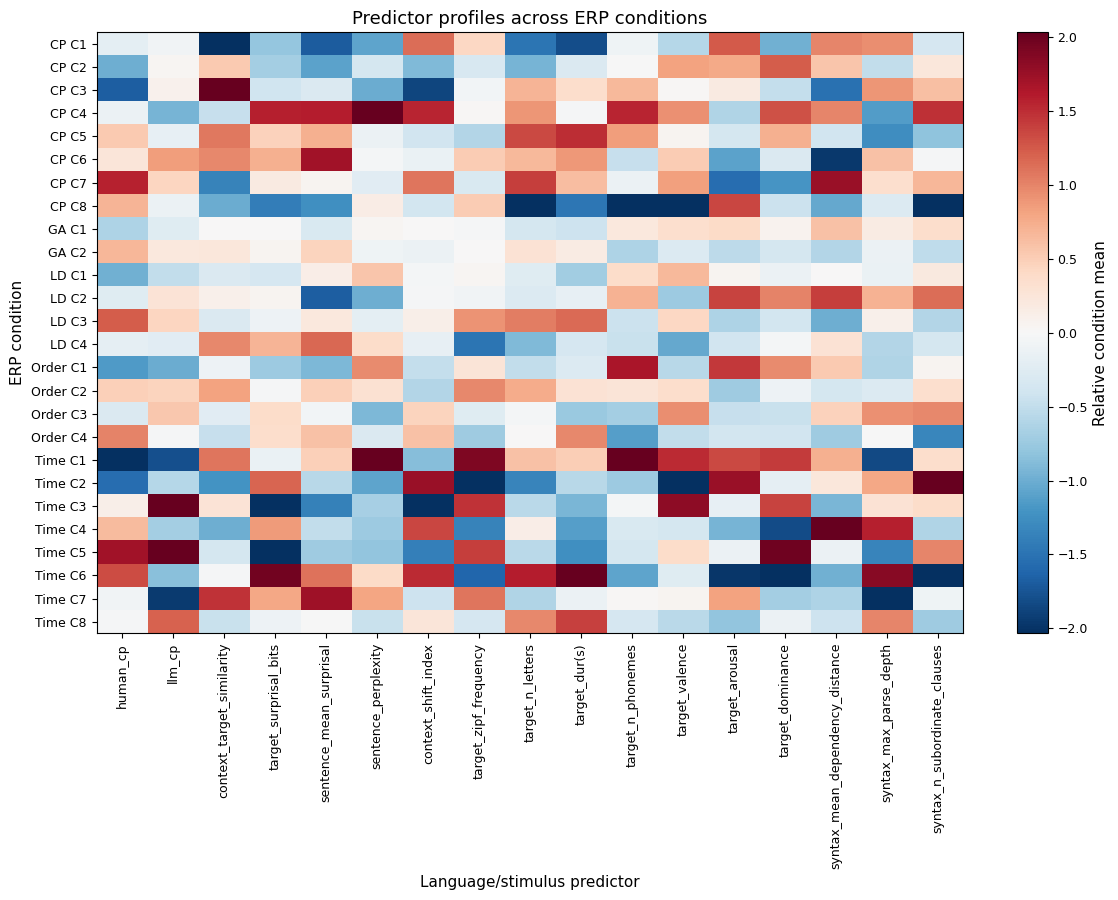

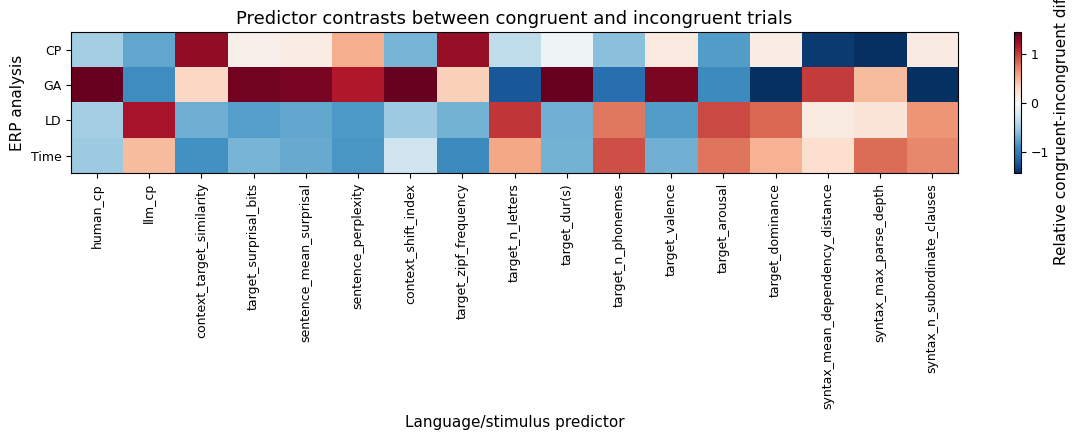

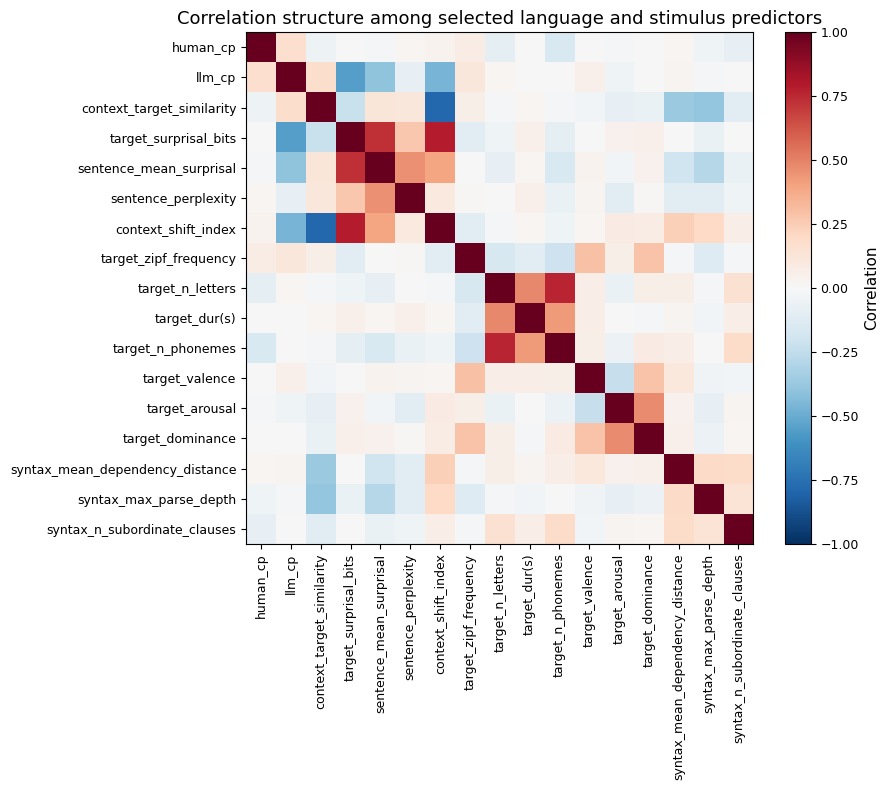

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, HTML

# ============================================================
# Input paths
# ============================================================

matrix_dir = Path("/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices")
predictors_path = Path(
    "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/"
    "language_outputs/ALL_language_metrics_GLM.tsv"
)

example_matrix_path = matrix_dir / "sub-01_erp-GA_design_matrix.tsv"

if not example_matrix_path.exists():
    matrix_files_check = sorted(matrix_dir.glob("*_design_matrix.tsv"))
    if len(matrix_files_check) == 0:
        raise FileNotFoundError(f"No design matrix files found in: {matrix_dir}")
    example_matrix_path = matrix_files_check[0]

# ============================================================
# Display helper
# ============================================================

def show_table(df, title=None, max_height="420px", wrap=True):
    if title is not None:
        display(HTML(f"""
        <h3 style="
            margin-top: 18px;
            margin-bottom: 8px;
            font-weight: bold;
        ">
            {title}
        </h3>
        """))

    html = df.to_html(index=False, escape=False)

    if wrap:
        td_style = """
            white-space: normal;
            word-break: normal;
            overflow-wrap: normal;
            max-width: 420px;
        """
    else:
        td_style = """
            white-space: nowrap;
            word-break: normal;
            overflow-wrap: normal;
            max-width: none;
        """

    display(HTML(f"""
    <div style="
        max-height: {max_height};
        overflow-y: auto;
        overflow-x: auto;
        border: 1px solid #999999;
        padding: 8px;
        font-size: 13px;
        margin-bottom: 18px;
        width: 100%;
    ">
        <style>
            table {{
                border-collapse: collapse;
                width: auto;
                min-width: 100%;
            }}

            th {{
                border: 1px solid #777777;
                padding: 7px;
                text-align: left;
                vertical-align: top;
                white-space: nowrap;
                background-color: #222222 !important;
                color: #ffffff !important;
                position: sticky;
                top: 0;
                z-index: 2;
                font-weight: bold;
            }}

            td {{
                border: 1px solid #dddddd;
                padding: 6px;
                text-align: left;
                vertical-align: top;
                {td_style}
            }}
        </style>
        {html}
    </div>
    """))

plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

display(HTML("""
<h2 style="font-weight: bold; margin-bottom: 16px;">
LIMO design matrices: ERP trial-level predictors for GLM modelling
</h2>
"""))

display(HTML("""
<p>
The LIMO design-matrix output adds the 19 language and stimulus-derived GLM predictors
to the retained ERP-trial lookup by matching each retained EEG trial to its stimulus through
<code>stim_key</code>. Each generated matrix is specific to one subject and one ERP analysis:
rows are retained EEG trials, and predictor columns are the explanatory variables used for
LIMO/GLM modelling.
</p>
"""))

# ============================================================
# Load generated design matrices
# ============================================================

matrix_files = sorted(matrix_dir.glob("*_design_matrix.tsv"))

if len(matrix_files) == 0:
    raise FileNotFoundError(f"No design matrix files found in: {matrix_dir}")

all_matrices = []

for path in matrix_files:
    df = pd.read_csv(path, sep="\t")
    df["matrix_file"] = path.name
    all_matrices.append(df)

matrices = pd.concat(all_matrices, ignore_index=True)

example_matrix = pd.read_csv(example_matrix_path, sep="\t")

# ============================================================
# Load predictor source table and define predictor columns
# ============================================================

predictor_source = pd.read_csv(
    predictors_path,
    sep=None,
    engine="python",
)

if "stim_key" not in predictor_source.columns:
    raise ValueError("The predictor source table does not contain stim_key.")

predictor_columns_from_source = [
    col for col in predictor_source.columns
    if col != "stim_key"
]

numeric_predictor_cols = []

for col in predictor_columns_from_source:
    if col in matrices.columns:
        matrices[col] = pd.to_numeric(matrices[col], errors="coerce")
        if matrices[col].notna().sum() > 0:
            numeric_predictor_cols.append(col)

for col in numeric_predictor_cols:
    if col in example_matrix.columns:
        example_matrix[col] = pd.to_numeric(example_matrix[col], errors="coerce")

# ============================================================
# Add short condition labels for readable heatmaps
# ============================================================

matrices["condition_plot_label"] = (
    matrices["analysis"].astype(str)
    + " C"
    + matrices["condition"].astype(str)
)

condition_key = (
    matrices[
        [
            "analysis",
            "condition",
            "condition_plot_label",
            "condition_label",
        ]
    ]
    .drop_duplicates()
    .sort_values(["analysis", "condition"])
    .reset_index(drop=True)
)

condition_key = condition_key[
    [
        "condition_plot_label",
        "condition_label",
    ]
]

# ============================================================
# 1. Predictor constructs
# ============================================================

predictor_constructs = {
    "target_dur(s)": "Target stimulus duration.",
    "human_cp": "Human cloze probability; target predictability based on human responses.",
    "n_words_sentence": "Sentence length.",
    "target_n_letters": "Orthographic length of the target word.",
    "target_zipf_frequency": "Lexical frequency of the target word on the Zipf scale.",
    "target_n_phonemes": "Phonological length of the target word.",
    "target_valence": "Affective valence of the target word.",
    "target_arousal": "Affective arousal associated with the target word.",
    "target_dominance": "Affective dominance/control rating associated with the target word.",
    "llm_cp": "Model-estimated cloze probability; computational predictability of the target.",
    "context_target_similarity": "Semantic similarity between the preceding sentence context and the target word.",
    "target_surprisal_bits": "Information-theoretic surprisal of the target word.",
    "sentence_mean_surprisal": "Mean surprisal across the sentence.",
    "sentence_perplexity": "Sentence-level perplexity; linguistic unpredictability of the full sentence.",
    "syntax_n_tokens": "Syntactic token count.",
    "syntax_mean_dependency_distance": "Mean dependency distance; syntactic integration demand.",
    "syntax_max_parse_depth": "Maximum parse depth; hierarchical syntactic complexity.",
    "syntax_n_subordinate_clauses": "Number of subordinate clauses; clausal complexity.",
    "context_shift_index": "Semantic/contextual shift between the preceding context and the target.",
}

predictor_table = pd.DataFrame(
    {
        "predictor": numeric_predictor_cols,
        "construct": [
            predictor_constructs.get(col, "")
            for col in numeric_predictor_cols
        ],
    }
)

show_table(
    predictor_table,
    "1. Language and stimulus-derived predictors in the LIMO design matrices",
    wrap=True,
)

# ============================================================
# 2. Condition-label key
# ============================================================

show_table(
    condition_key,
    "2. Condition-label key for heatmaps",
    wrap=True,
)

# ============================================================
# 3. Example rows from one subject-analysis design matrix
# ============================================================

predictors_to_show = [
    col for col in [
        "human_cp",
        "llm_cp",
        "context_target_similarity",
        "target_surprisal_bits",
        "sentence_mean_surprisal",
        "sentence_perplexity",
        "syntax_mean_dependency_distance",
        "context_shift_index",
    ]
    if col in numeric_predictor_cols
]

first_rows_cols = [
    "subject",
    "analysis",
    "condition_plot_label",
    "condition_label",
    "eeg_trial",
    "stim_key",
    "trial_type",
] + predictors_to_show

first_rows_cols = [
    col for col in first_rows_cols
    if col in example_matrix.columns or col == "condition_plot_label"
]

example_matrix["condition_plot_label"] = (
    example_matrix["analysis"].astype(str)
    + " C"
    + example_matrix["condition"].astype(str)
)

first_rows = example_matrix[first_rows_cols].head(15).copy()

show_table(
    first_rows,
    f"3. Example rows from one subject-analysis LIMO design matrix: {example_matrix_path.name}",
    max_height="360px",
    wrap=False,
)

# ============================================================
# 4. Predictor descriptive statistics
# ============================================================

predictor_summary = (
    matrices[numeric_predictor_cols]
    .agg(["mean", "std", "min", "max"])
    .T
    .reset_index()
    .rename(
        columns={
            "index": "predictor",
            "mean": "mean",
            "std": "sd",
            "min": "min",
            "max": "max",
        }
    )
)

for col in ["mean", "sd", "min", "max"]:
    predictor_summary[col] = predictor_summary[col].round(3)

predictor_summary["missing_values"] = [
    int(matrices[col].isna().sum())
    for col in predictor_summary["predictor"]
]

show_table(
    predictor_summary,
    "4. Descriptive statistics for language and stimulus predictors",
    wrap=False,
)

# ============================================================
# 5. Predictor summaries by ERP condition
# ============================================================

condition_summary_rows = []

if "condition_label" in matrices.columns:
    for predictor in numeric_predictor_cols:
        temp = (
            matrices
            .groupby(["analysis", "condition_plot_label", "condition_label"])[predictor]
            .agg(["mean", "std"])
            .reset_index()
        )

        temp["predictor"] = predictor
        condition_summary_rows.append(temp)

if condition_summary_rows:
    condition_summary = pd.concat(condition_summary_rows, ignore_index=True)
    condition_summary = condition_summary[
        [
            "analysis",
            "condition_plot_label",
            "condition_label",
            "predictor",
            "mean",
            "std",
        ]
    ].rename(columns={"std": "sd"})

    for col in ["mean", "sd"]:
        condition_summary[col] = condition_summary[col].round(3)

    show_table(
        condition_summary,
        "5. Predictor summaries by ERP analysis and experimental condition",
        max_height="520px",
        wrap=False,
    )

# ============================================================
# Define predictors for the heatmaps
# ============================================================

profile_predictors = [
    "human_cp",
    "llm_cp",
    "context_target_similarity",
    "target_surprisal_bits",
    "sentence_mean_surprisal",
    "sentence_perplexity",
    "context_shift_index",
    "target_zipf_frequency",
    "target_n_letters",
    "target_dur(s)",
    "target_n_phonemes",
    "target_valence",
    "target_arousal",
    "target_dominance",
    "syntax_mean_dependency_distance",
    "syntax_max_parse_depth",
    "syntax_n_subordinate_clauses",
]

profile_predictors = [
    col for col in profile_predictors
    if col in numeric_predictor_cols
]

# ============================================================
# 6. Condition-level predictor profile heatmap
# ============================================================

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
6. Condition-level predictor profile heatmap
</h3>
<p style="margin-top: 0;">
This heatmap shows whether each ERP condition has relatively higher or lower values
on each language/stimulus predictor. Rows are ERP conditions; columns are predictors.
</p>
"""))

condition_profiles = (
    matrices
    .groupby(["analysis", "condition", "condition_plot_label"])[profile_predictors]
    .mean()
    .reset_index()
    .sort_values(["analysis", "condition"])
)

condition_profile_matrix = (
    condition_profiles
    .set_index("condition_plot_label")[profile_predictors]
)

condition_profile_display = condition_profile_matrix.copy()

for col in condition_profile_display.columns:
    col_sd = condition_profile_display[col].std()

    if pd.notna(col_sd) and col_sd != 0:
        condition_profile_display[col] = (
            condition_profile_display[col]
            - condition_profile_display[col].mean()
        ) / col_sd
    else:
        condition_profile_display[col] = 0

condition_profile_display = condition_profile_display.fillna(0)

condition_values = condition_profile_display.values
condition_limit = np.nanpercentile(np.abs(condition_values), 95)
if pd.isna(condition_limit) or condition_limit == 0:
    condition_limit = 1

plt.figure(figsize=(12, max(6, 0.35 * len(condition_profile_display))))
plt.imshow(
    condition_profile_display.values,
    aspect="auto",
    interpolation="nearest",
    cmap="RdBu_r",
    vmin=-condition_limit,
    vmax=condition_limit,
)
plt.colorbar(label="Relative condition mean")
plt.xlabel("Language/stimulus predictor")
plt.ylabel("ERP condition")
plt.title("Predictor profiles across ERP conditions")
plt.xticks(
    ticks=np.arange(len(condition_profile_display.columns)),
    labels=condition_profile_display.columns,
    rotation=90,
)
plt.yticks(
    ticks=np.arange(len(condition_profile_display.index)),
    labels=condition_profile_display.index,
)
plt.tight_layout()
plt.show()

# ============================================================
# 7. Congruent-minus-incongruent predictor contrast heatmap
# ============================================================

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
7. Congruent-minus-incongruent predictor contrast heatmap
</h3>
<p style="margin-top: 0;">
This heatmap shows the predictor difference between congruent and incongruent trials
within each ERP analysis. Positive values mean the predictor is higher for congruent trials;
negative values mean it is higher for incongruent trials.
</p>
"""))

def get_congruence_group(label):
    label = str(label).lower()

    if "incongruent" in label or "inongruent" in label:
        return "Incongruent"

    if "congruent" in label:
        return "Congruent"

    return "Other"

matrices["congruence_group"] = matrices["condition_label"].apply(get_congruence_group)

congruence_means = (
    matrices[
        matrices["congruence_group"].isin(["Congruent", "Incongruent"])
    ]
    .groupby(["analysis", "congruence_group"])[profile_predictors]
    .mean()
    .reset_index()
)

contrast_rows = []

for analysis in sorted(congruence_means["analysis"].dropna().unique()):
    analysis_data = congruence_means[
        congruence_means["analysis"].eq(analysis)
    ]

    if (
        "Congruent" in analysis_data["congruence_group"].values
        and "Incongruent" in analysis_data["congruence_group"].values
    ):
        congruent_values = (
            analysis_data[
                analysis_data["congruence_group"].eq("Congruent")
            ][profile_predictors]
            .iloc[0]
        )

        incongruent_values = (
            analysis_data[
                analysis_data["congruence_group"].eq("Incongruent")
            ][profile_predictors]
            .iloc[0]
        )

        difference = congruent_values - incongruent_values
        difference["analysis"] = analysis
        contrast_rows.append(difference)

if contrast_rows:
    contrast_df = pd.DataFrame(contrast_rows).set_index("analysis")
    contrast_df = contrast_df[profile_predictors]

    # Standardise by predictor so colours show relative contrast patterns.
    contrast_display = contrast_df.copy()

    for col in contrast_display.columns:
        col_sd = contrast_display[col].std()

        if pd.notna(col_sd) and col_sd != 0:
            contrast_display[col] = (
                contrast_display[col]
                - contrast_display[col].mean()
            ) / col_sd
        else:
            contrast_display[col] = 0

    contrast_display = contrast_display.fillna(0)

    contrast_values = contrast_display.values
    contrast_limit = np.nanpercentile(np.abs(contrast_values), 95)
    if pd.isna(contrast_limit) or contrast_limit == 0:
        contrast_limit = 1

    plt.figure(figsize=(12, 4.5))
    plt.imshow(
        contrast_display.values,
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=-contrast_limit,
        vmax=contrast_limit,
    )
    plt.colorbar(label="Relative congruent-incongruent difference")
    plt.xlabel("Language/stimulus predictor")
    plt.ylabel("ERP analysis")
    plt.title("Predictor contrasts between congruent and incongruent trials")
    plt.xticks(
        ticks=np.arange(len(contrast_display.columns)),
        labels=contrast_display.columns,
        rotation=90,
    )
    plt.yticks(
        ticks=np.arange(len(contrast_display.index)),
        labels=contrast_display.index,
    )
    plt.tight_layout()
    plt.show()

# ============================================================
# 8. Predictor correlation matrix
# ============================================================

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
8. Predictor correlation matrix
</h3>
<p style="margin-top: 0;">
This matrix shows which language/stimulus predictors covary across retained EEG trials.
It is useful before GLM/LIMO modelling because highly correlated predictors can carry
overlapping explanatory information.
</p>
"""))

if len(profile_predictors) > 1:
    corr = matrices[profile_predictors].corr()

    plt.figure(figsize=(9, 8))
    plt.imshow(
        corr.values,
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
    )
    plt.colorbar(label="Correlation")
    plt.xticks(
        ticks=np.arange(len(corr.columns)),
        labels=corr.columns,
        rotation=90,
    )
    plt.yticks(
        ticks=np.arange(len(corr.index)),
        labels=corr.index,
    )
    plt.title("Correlation structure among selected language and stimulus predictors")
    plt.tight_layout()
    plt.show()

In [17]:
#%cd /content/Semantically_Incongruent_or_Congruent_Eggplants_revised
#!zip -r /content/limo_design_matrices.zip limo_design_matrices

#from google.colab import files
#files.download("/content/limo_design_matrices.zip")

/content/Semantically_Incongruent_or_Congruent_Eggplants_revised
	zip warning: name not matched: limo_design_matrices

zip error: Nothing to do! (try: zip -r /content/limo_design_matrices.zip . -i limo_design_matrices)


In [18]:
!unzip -o limo_design_matrices.zip -d /content/Semantically_Incongruent_or_Congruent_Eggplants_revised

Archive:  limo_design_matrices.zip
   creating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-09_erp-Order_design_matrix.tsv  
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-08_erp-Time_design_matrix.tsv  
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-08_erp-GA_design_matrix.tsv  
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-16_erp-GA_design_matrix.tsv  
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-16_erp-LD_design_matrix.tsv  
  inflating: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-23_erp-CP_design_matrix.tsv  
  inflating: /content/Semantically_Incongruent_or_Congruent_Eg

# Run trial-level mass-univariate EEG/ERP GLMs

This section runs the trial-level ERP regression-modelling step using the preprocessed ERP derivative MAT files from the N400Stimset dataset (Toffolo et al., 2022) and the trial-level design matrices created in the previous step.

For each subject, `erp_analysis/run_mass_univariate_erp_glm.py` processes each available CP, GA, LD, Order, or Time ERP MAT file separately. Each ERP MAT file is matched to its corresponding trial-level design matrix: the MAT file provides the retained single-trial ERP amplitudes, while the design matrix provides the language-predictor values for the stimulus presented on each retained trial. Before fitting the model, the script verifies that the retained trials in the MAT file correspond to the rows of the design matrix using trial order and `eventurevent` / `urevent_index`.

For each matched ERP MAT file and design matrix, the script fits a general linear model separately at every electrode and timepoint, with single-trial ERP amplitude as the dependent variable and the selected trial-level language predictors as independent variables. The predictors include expectancy, surprisal, semantic, lexical, phonological, syntactic, and affective measures. This allows the analysis to move beyond condition-level ERP comparisons and estimate how continuous properties of the sentence-final word relate to the ERP signal on individual retained trials.

The script writes one results folder for each fitted subject and ERP MAT file. The model output is stored in `erp_glm_results.h5`, which contains the beta maps, t-value maps, residual variance, the numeric design matrix used in the model, the ERP time vector, the valid-trial mask, predictor names, channel names, and model metadata. The metadata stored in this file includes the input files, number of trials, number of channels, number of timepoints, number of predictors, model rank, degrees of freedom, intercept setting, and trial-alignment information.

The resulting files provide subject-specific estimates of how sentence-final expectancy, surprisal, semantic fit, lexical properties, phonological structure, syntactic complexity, and affective tone vary with retained single-trial ERP amplitude across electrodes and time. This makes it possible to examine whether the variables generated in the stimulus analysis align with ERP activity in the RP, N400/PN400, and LPC/P600 time ranges.

In [19]:
!python erp_analysis/run_mass_univariate_erp_glm.py \
  --design-dir "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices" \
  --output-root "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/erp_glm_outputs" \
  --erp-root "/content/drive/MyDrive/N400/erps" \
  --subjects ALL \
  --analyses ALL \
  --predictor-list "target_dur(s),human_cp,n_words_sentence,target_n_letters,target_zipf_frequency,target_n_phonemes,target_valence,target_arousal,target_dominance,llm_cp,context_target_similarity,target_surprisal_bits,sentence_mean_surprisal,sentence_perplexity,syntax_n_tokens,syntax_mean_dependency_distance,syntax_max_parse_depth,syntax_n_subordinate_clauses,context_shift_index" \
  --skip-existing

Streaming output truncated to the last 5000 lines.
  "n_channels": 128,
  "n_times": 615,
  "n_predictors_including_intercept": 20,
  "rank": 19,
  "dof": 166,
  "hdf5_output": "/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/erp_glm_outputs/sub-03/erp-Time/erp_glm_results.h5",
  "error": ""
}

Subject: sub-04
Analysis: CP
ERP MAT: /content/drive/MyDrive/N400/erps/sub-04/sub-04_task-N400Stimset_erp-CP.mat
Design: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/limo_design_matrices/sub-04_erp-CP_design_matrix.tsv
Output: /content/Semantically_Incongruent_or_Congruent_Eggplants_revised/erp_glm_outputs/sub-04/erp-CP
Design rows: 377
EEG data shape: (377, 128, 615) = trials x channels x times
HDF5 group: ERPs
Raw data shape: (377, 128, 615)
Verified EEG/design alignment using eventurevent == urevent_index.
Selected 19 predictor columns.
Predictors used:
  - target_dur(s)
  - human_cp
  - n_words_sentence
  - target_n_letters
  - target_zipf_frequency
  - t

In [20]:
!zip -r erp_glm_outputs.zip erp_glm_outputs

  adding: erp_glm_outputs/ (stored 0%)
  adding: erp_glm_outputs/sub-13/ (stored 0%)
  adding: erp_glm_outputs/sub-13/erp-Time/ (stored 0%)
  adding: erp_glm_outputs/sub-13/erp-Time/erp_glm_results.h5 (deflated 0%)
  adding: erp_glm_outputs/sub-13/erp-CP/ (stored 0%)
  adding: erp_glm_outputs/sub-13/erp-CP/erp_glm_results.h5 (deflated 0%)
  adding: erp_glm_outputs/sub-13/erp-Order/ (stored 0%)
  adding: erp_glm_outputs/sub-13/erp-Order/erp_glm_results.h5 (deflated 0%)
  adding: erp_glm_outputs/sub-13/erp-GA/ (stored 0%)
  adding: erp_glm_outputs/sub-13/erp-GA/erp_glm_results.h5 (deflated 0%)
  adding: erp_glm_outputs/sub-13/erp-LD/ (stored 0%)
  adding: erp_glm_outputs/sub-13/erp-LD/erp_glm_results.h5 (deflated 0%)
  adding: erp_glm_outputs/sub-17/ (stored 0%)
  adding: erp_glm_outputs/sub-17/erp-Time/ (stored 0%)
  adding: erp_glm_outputs/sub-17/erp-Time/erp_glm_results.h5 (deflated 0%)
  adding: erp_glm_outputs/sub-17/erp-CP/ (stored 0%)
  adding: erp_glm_outputs/sub-17/erp-CP/erp_gl

In [22]:
from google.colab import files
files.download("/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/erp_glm_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

measure,value
fitted_models,104
subjects,24
erp_divisions,5
predictors,19


erp_division,description
GA,Grand average: congruent vs incongruent
CP,Cloze probability: congruent/incongruent trials separated by cloze-probability group
LD,Linguistic division: semantic-only errors vs combined semantic/syntactic errors
Order,Presentation order: whether the congruent or incongruent paired sentence was presented first
Time,Experiment time: trials separated by quarter of the experiment


predictor,description
target_dur(s),Duration of the spoken sentence-final target word in seconds. This captures acoustic exposure time and controls for differences in how long the auditory target was physically present.
human_cp,"Human cloze probability for the target word. This is the proportion of human responses predicting the same target from the preceding context, so higher values indicate greater human expectancy."
n_words_sentence,Total number of words in the sentence. This captures sentence length and the amount of preceding linguistic context available before the final target word.
target_n_letters,Number of letters in the target word. This is a word-form length measure included as a lexical control.
target_zipf_frequency,"Zipf-scale lexical frequency of the target word. Higher values indicate more frequent words, which are generally easier to access lexically."
target_n_phonemes,Number of phonemes in the spoken target word. This captures phonological length and controls for complexity of the auditory word form.
target_valence,Valence rating of the target word. Higher values indicate more positive or pleasant affective meaning.
target_arousal,Arousal rating of the target word. Higher values indicate more emotionally activating or intense word meaning.
target_dominance,"Dominance rating of the target word. Higher values indicate stronger associations with control, power, or agency."
llm_cp,Language-model cloze probability for the target word given the preceding context. Higher values indicate that the model assigned higher contextual probability to the observed target.


erp_division,n_models,n_subjects,mean_trials_used,min_trials_used,max_trials_used,n_channels,n_timepoints,n_predictors_including_intercept,min_rank,max_rank,min_degrees_of_freedom,max_degrees_of_freedom
CP,20,20,342.55,182,387,128.0,615.0,20.0,19,19,163,368
GA,24,24,339.00,154,428,128.0,615.0,20.0,19,19,135,409
LD,20,20,346.00,184,391,128.0,615.0,20.0,18,19,166,372
Order,20,20,346.10,185,391,128.0,615.0,20.0,19,19,166,372
Time,20,20,346.10,185,391,128.0,615.0,20.0,19,19,166,372


erp_division,predictor,erp_window,n_subjects,mean_beta_across_subjects,mean_t_across_subjects,mean_abs_t_across_subjects,mean_peak_abs_t_across_subjects,median_peak_time_ms,n_beta_positive,n_beta_negative,percent_beta_positive,percent_beta_negative,dominant_direction,direction_consistency_percent
LD,llm_cp,LPC/P600 500-800 ms,20,-5.431233e-10,-0.060598,0.852669,3.426694,619.140625,13,7,65.000000,35.000000,positive,65.000000
Order,llm_cp,LPC/P600 500-800 ms,20,-6.177928e-10,-0.060852,0.844290,3.412029,630.859375,12,8,60.000000,40.000000,positive,60.000000
Time,llm_cp,LPC/P600 500-800 ms,20,-6.177928e-10,-0.060852,0.844290,3.412029,630.859375,12,8,60.000000,40.000000,positive,60.000000
CP,llm_cp,LPC/P600 500-800 ms,20,-5.323069e-10,-0.062898,0.845195,3.411470,630.859375,12,8,60.000000,40.000000,positive,60.000000
GA,target_arousal,LPC/P600 500-800 ms,24,-2.439076e-09,-0.036616,0.799984,3.389575,610.351562,11,13,45.833333,54.166667,negative,54.166667
Order,target_valence,LPC/P600 500-800 ms,20,2.128378e-09,-0.034353,0.895106,3.374045,609.375000,13,7,65.000000,35.000000,positive,65.000000
Time,target_valence,LPC/P600 500-800 ms,20,2.128378e-09,-0.034353,0.895106,3.374045,609.375000,13,7,65.000000,35.000000,positive,65.000000
LD,target_valence,LPC/P600 500-800 ms,20,2.190597e-09,-0.035502,0.891293,3.365798,609.375000,13,7,65.000000,35.000000,positive,65.000000
GA,target_n_phonemes,LPC/P600 500-800 ms,24,-1.899851e-09,-0.003887,0.829878,3.365420,633.789062,12,12,50.000000,50.000000,mixed,50.000000
CP,target_valence,LPC/P600 500-800 ms,20,1.834111e-09,-0.034574,0.888220,3.364680,597.656250,12,8,60.000000,40.000000,positive,60.000000


erp_division,predictor,erp_window,n_subjects,mean_beta_across_subjects,mean_t_across_subjects,mean_abs_t_across_subjects,mean_peak_abs_t_across_subjects,median_peak_time_ms,n_beta_positive,n_beta_negative,percent_beta_positive,percent_beta_negative,dominant_direction,direction_consistency_percent,label
LD,llm_cp,LPC/P600 500-800 ms,20,-5.431233e-10,-0.060598,0.852669,3.426694,619.140625,13,7,65.000000,35.000000,positive,65.000000,LPC/P600 500-800 ms | LD | llm_cp
Order,llm_cp,LPC/P600 500-800 ms,20,-6.177928e-10,-0.060852,0.844290,3.412029,630.859375,12,8,60.000000,40.000000,positive,60.000000,LPC/P600 500-800 ms | Order | llm_cp
Time,llm_cp,LPC/P600 500-800 ms,20,-6.177928e-10,-0.060852,0.844290,3.412029,630.859375,12,8,60.000000,40.000000,positive,60.000000,LPC/P600 500-800 ms | Time | llm_cp
CP,llm_cp,LPC/P600 500-800 ms,20,-5.323069e-10,-0.062898,0.845195,3.411470,630.859375,12,8,60.000000,40.000000,positive,60.000000,LPC/P600 500-800 ms | CP | llm_cp
GA,target_arousal,LPC/P600 500-800 ms,24,-2.439076e-09,-0.036616,0.799984,3.389575,610.351562,11,13,45.833333,54.166667,negative,54.166667,LPC/P600 500-800 ms | GA | target_arousal
Order,target_valence,LPC/P600 500-800 ms,20,2.128378e-09,-0.034353,0.895106,3.374045,609.375000,13,7,65.000000,35.000000,positive,65.000000,LPC/P600 500-800 ms | Order | target_valence
Time,target_valence,LPC/P600 500-800 ms,20,2.128378e-09,-0.034353,0.895106,3.374045,609.375000,13,7,65.000000,35.000000,positive,65.000000,LPC/P600 500-800 ms | Time | target_valence
LD,target_valence,LPC/P600 500-800 ms,20,2.190597e-09,-0.035502,0.891293,3.365798,609.375000,13,7,65.000000,35.000000,positive,65.000000,LPC/P600 500-800 ms | LD | target_valence
GA,target_n_phonemes,LPC/P600 500-800 ms,24,-1.899851e-09,-0.003887,0.829878,3.365420,633.789062,12,12,50.000000,50.000000,mixed,50.000000,LPC/P600 500-800 ms | GA | target_n_phonemes
CP,target_valence,LPC/P600 500-800 ms,20,1.834111e-09,-0.034574,0.888220,3.364680,597.656250,12,8,60.000000,40.000000,positive,60.000000,LPC/P600 500-800 ms | CP | target_valence


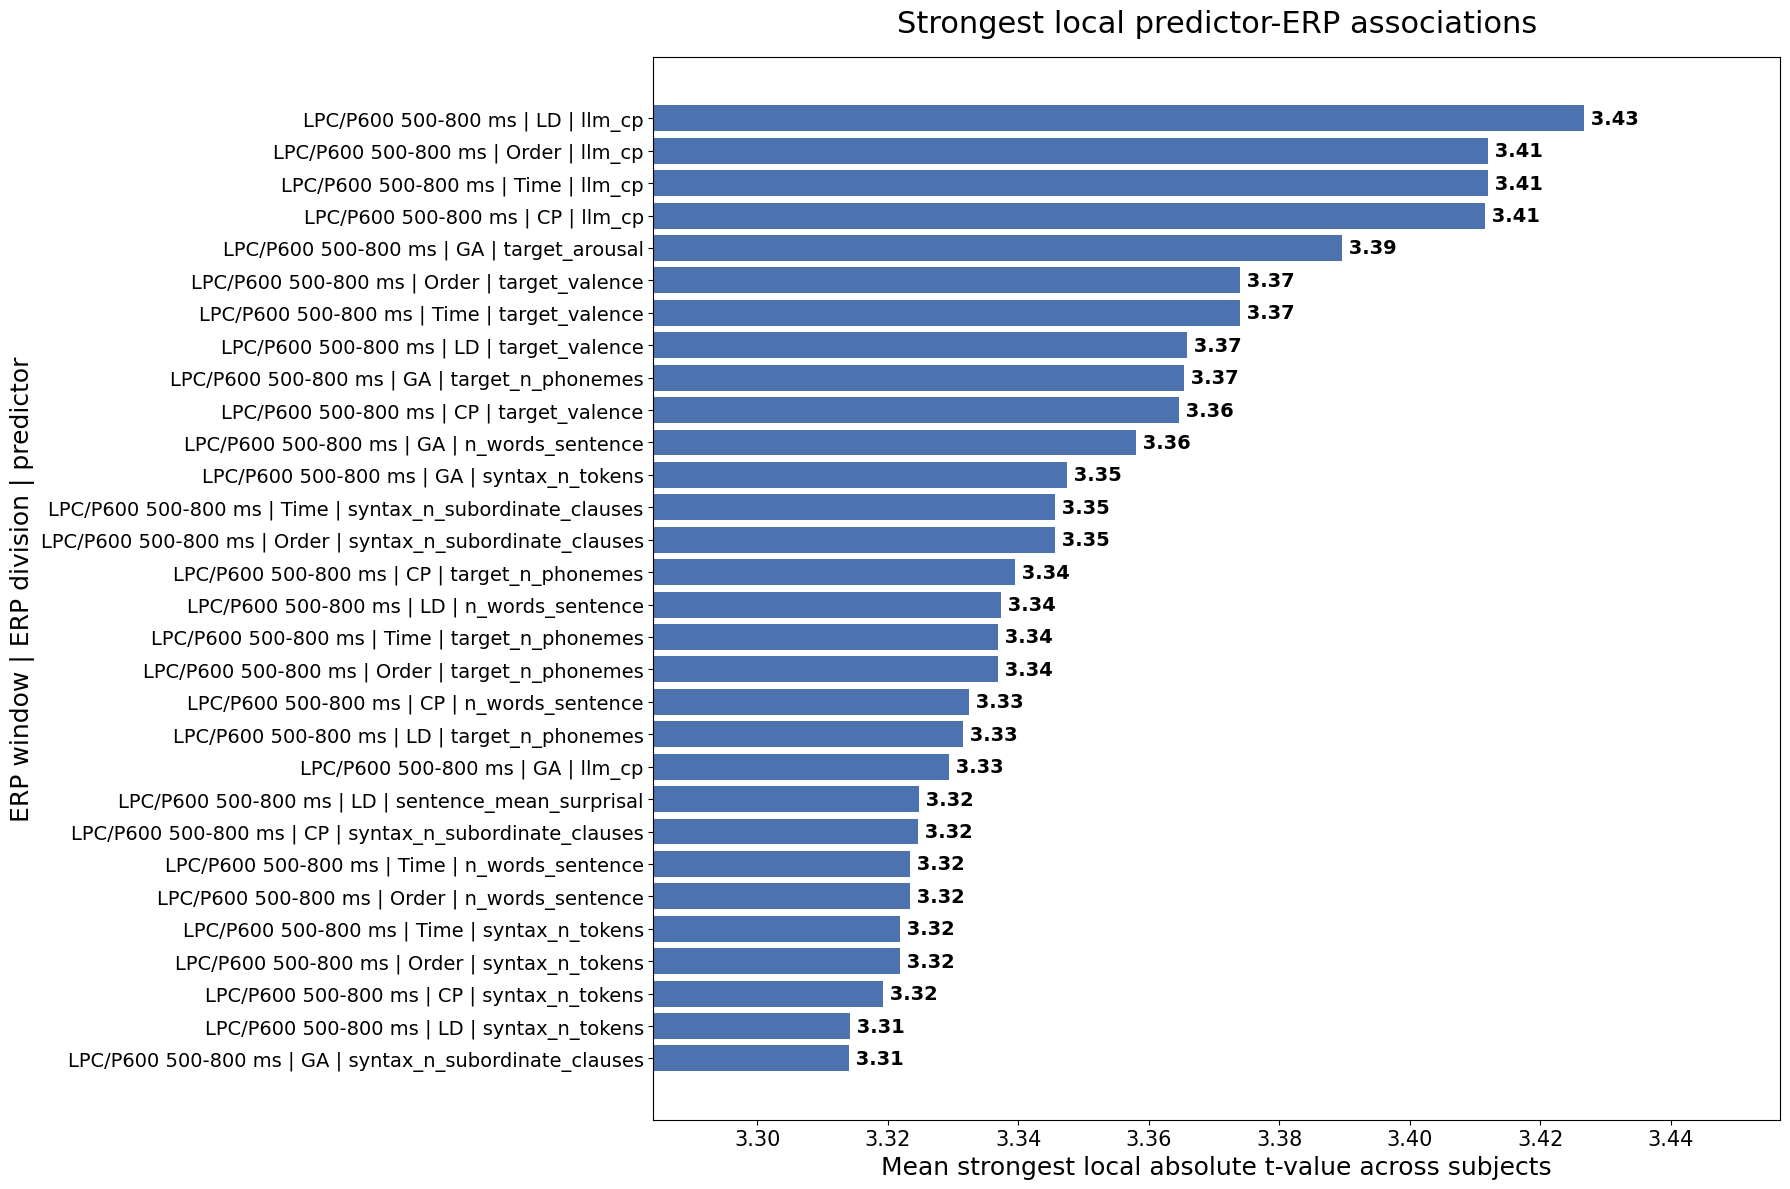

erp_division,predictor,GA,CP,LD,Order,Time
,target_dur(s),0.015117,0.022269,0.019508,0.021535,0.021535
,human_cp,0.018693,0.014033,0.015487,0.015462,0.015462
,n_words_sentence,-0.013567,-0.009006,0.016488,-0.010785,-0.010785
,target_n_letters,-0.003407,-0.033790,-0.031275,-0.032828,-0.032828
,target_zipf_frequency,-0.011651,-0.011171,-0.026832,-0.017799,-0.017799
,target_n_phonemes,-0.024458,-0.010511,-0.013324,-0.012613,-0.012613
,target_valence,0.018107,0.011765,0.016409,0.015465,0.015465
,target_arousal,-0.024344,-0.012774,-0.016581,-0.014997,-0.014997
,target_dominance,-0.006008,-0.027001,-0.020348,-0.023052,-0.023052
,llm_cp,-0.059397,-0.047664,-0.049311,-0.046281,-0.046281


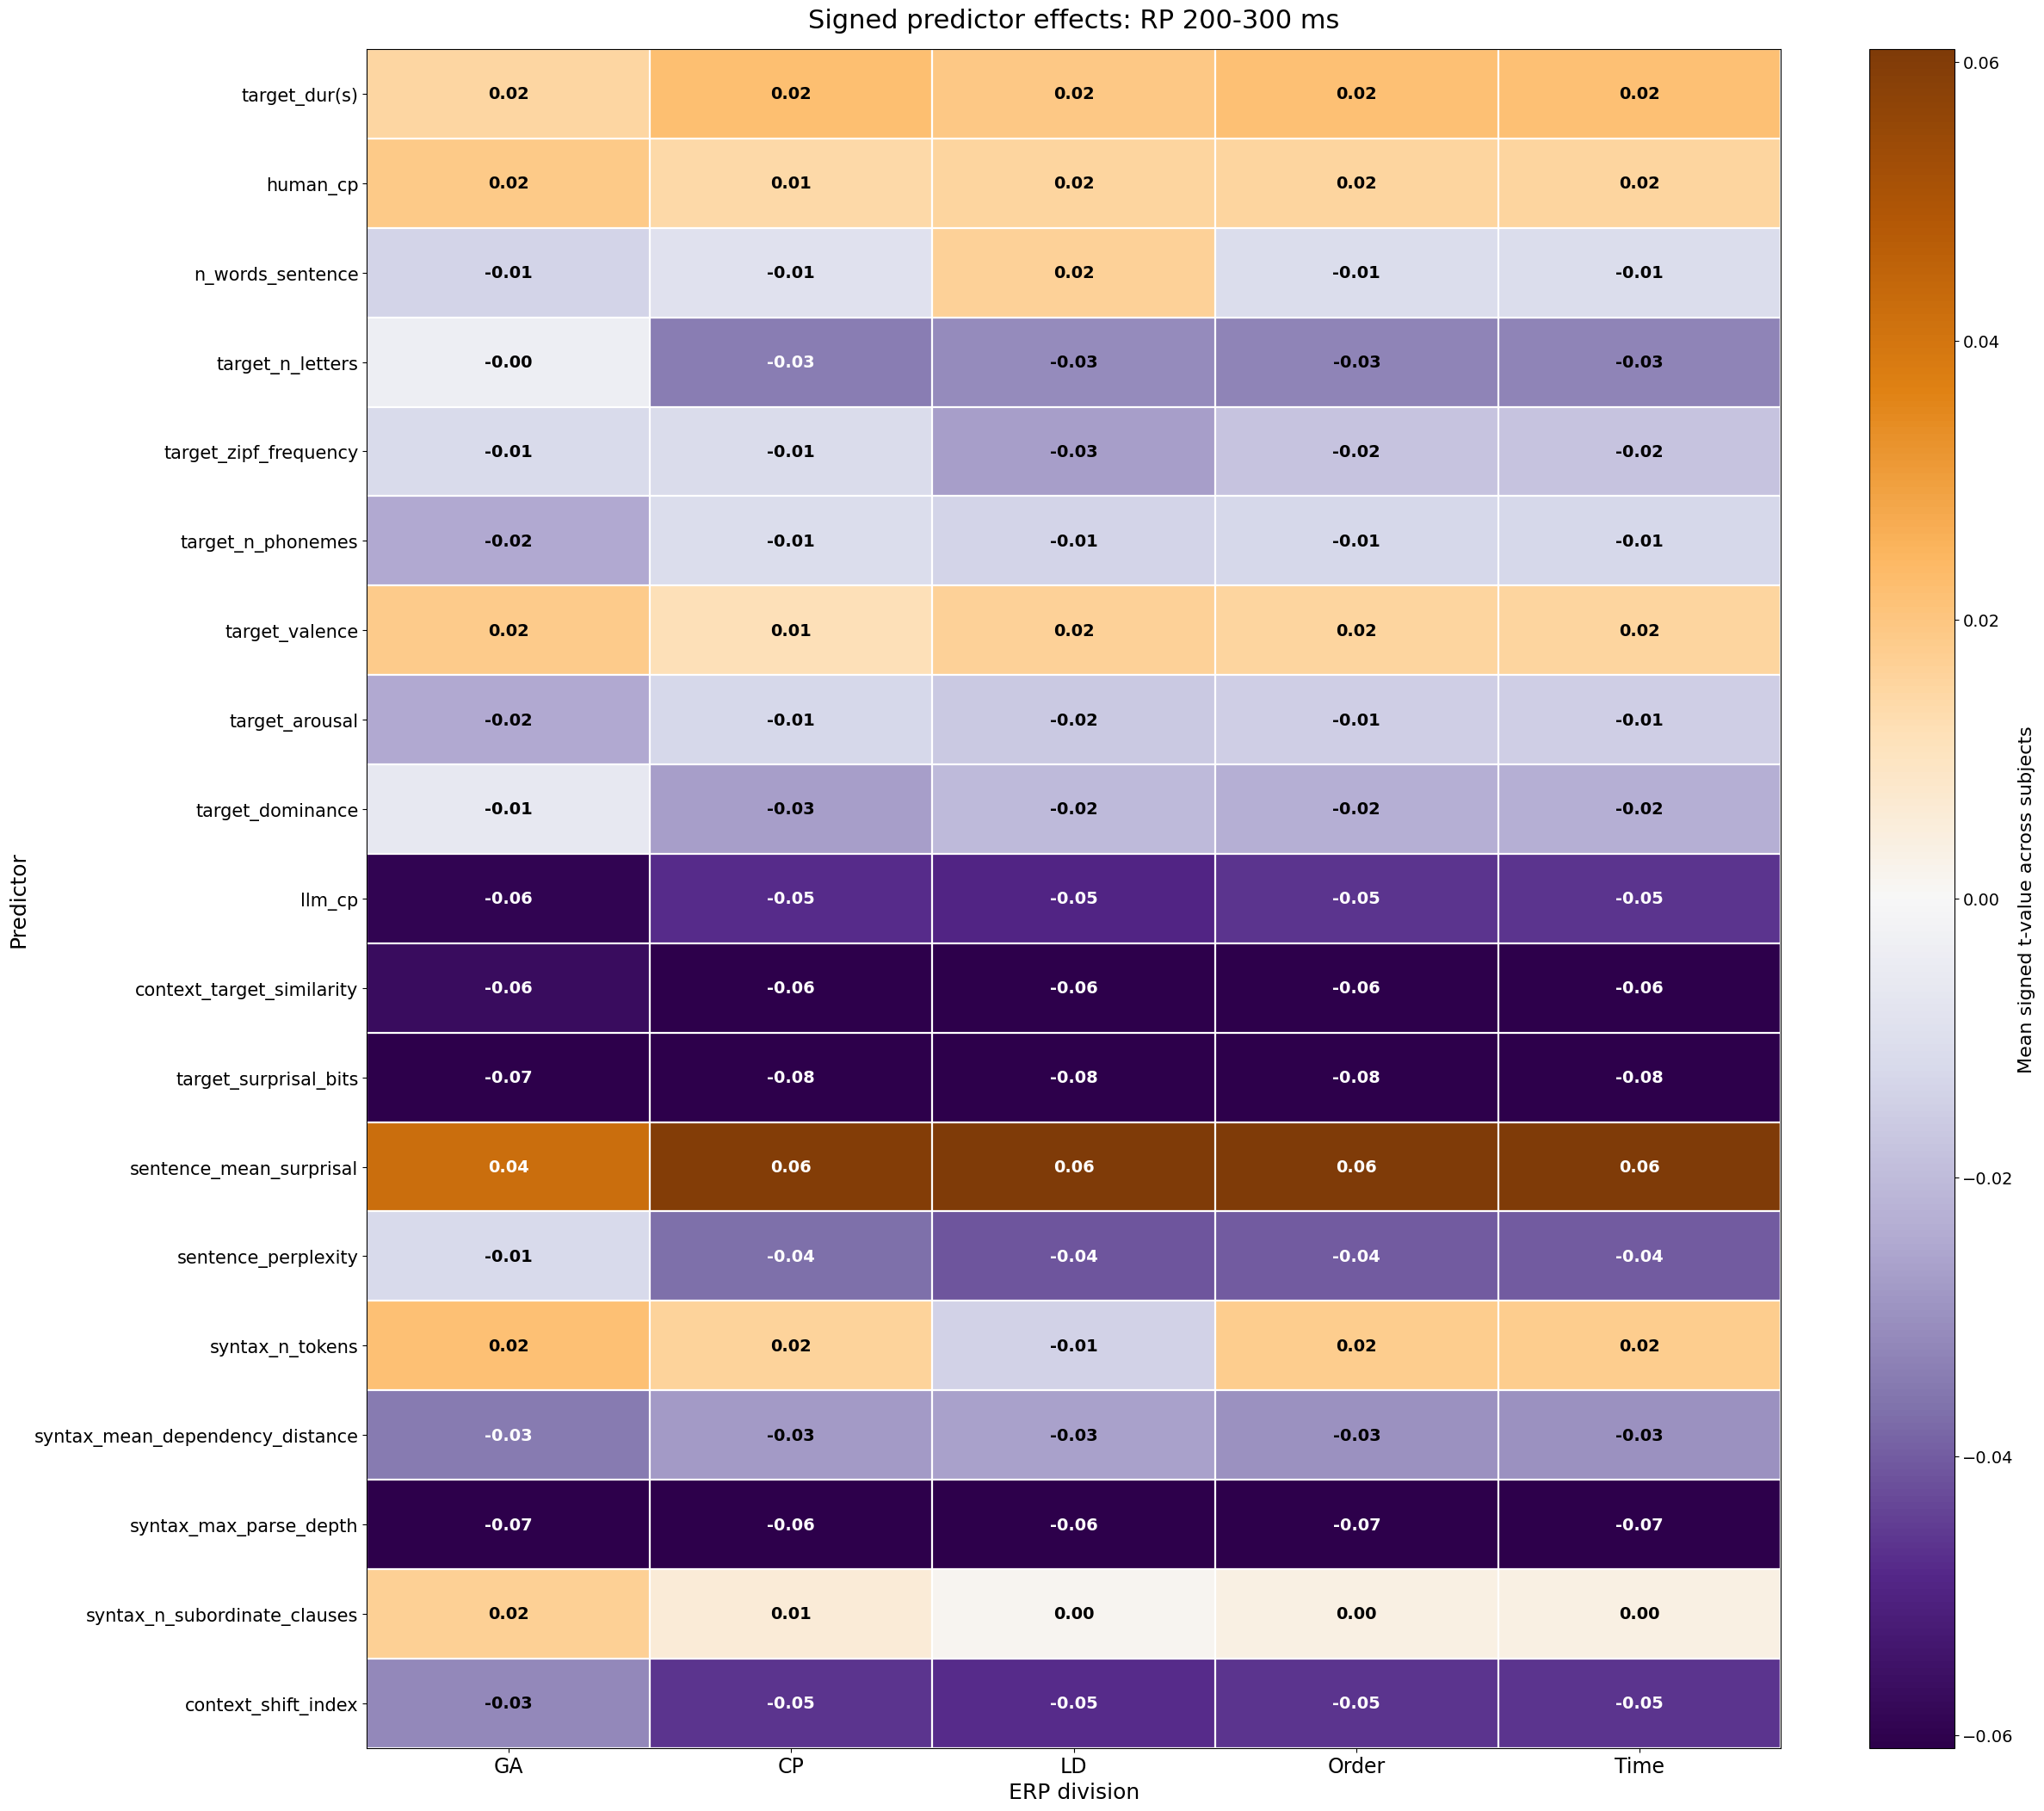

erp_division,predictor,GA,CP,LD,Order,Time
,target_dur(s),-0.009771,0.000349,-0.005361,-0.001882,-0.001882
,human_cp,0.021111,0.017570,0.013735,0.019226,0.019226
,n_words_sentence,-0.003160,0.010732,0.037074,0.008790,0.008790
,target_n_letters,-0.027329,-0.047851,-0.042403,-0.045288,-0.045288
,target_zipf_frequency,-0.017994,-0.012845,-0.020932,-0.013543,-0.013543
,target_n_phonemes,0.006806,-0.000653,-0.004112,-0.002332,-0.002332
,target_valence,0.030283,0.010503,0.008995,0.011131,0.011131
,target_arousal,-0.019757,-0.006314,-0.015339,-0.010458,-0.010458
,target_dominance,-0.016257,-0.023665,-0.015830,-0.020095,-0.020095
,llm_cp,-0.050194,-0.035128,-0.034950,-0.033786,-0.033786


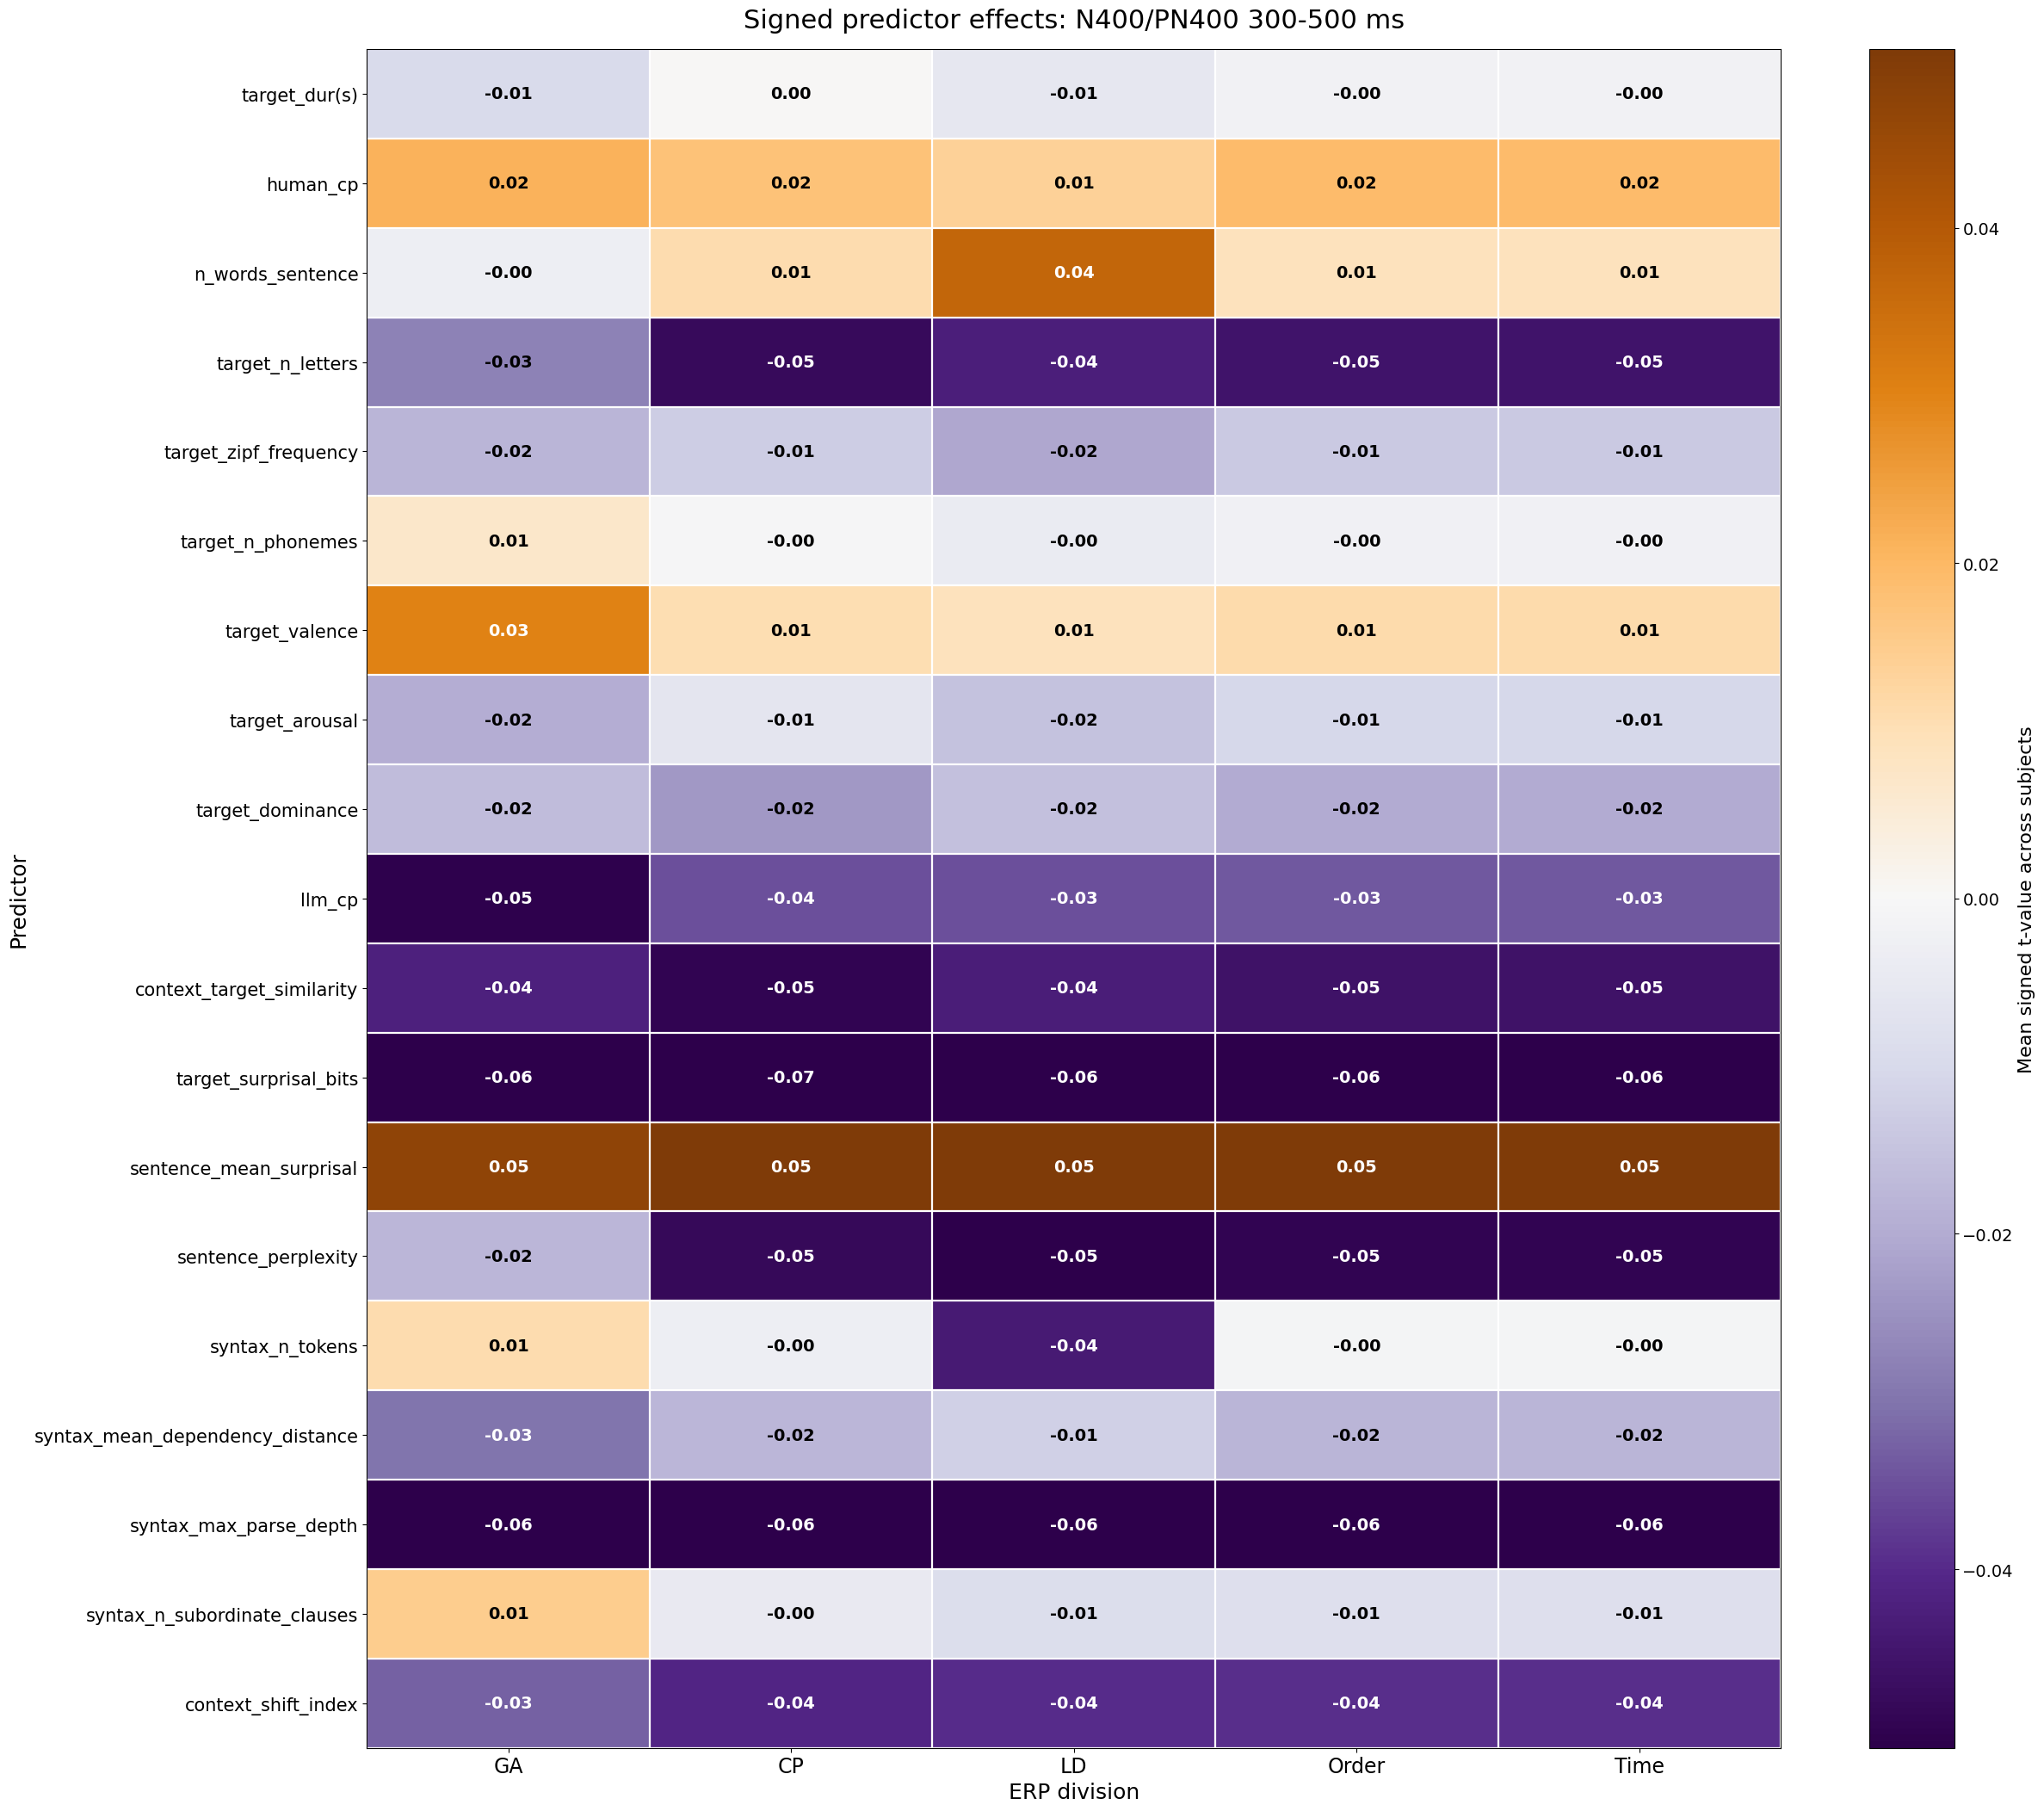

erp_division,predictor,GA,CP,LD,Order,Time
,target_dur(s),-0.025764,-0.024061,-0.025115,-0.021982,-0.021982
,human_cp,-0.005454,0.013640,0.011315,0.011406,0.011406
,n_words_sentence,0.021725,0.029317,0.051053,0.028598,0.028598
,target_n_letters,-0.007519,-0.012462,-0.011738,-0.012742,-0.012742
,target_zipf_frequency,0.017581,0.003650,-0.002033,0.003328,0.003328
,target_n_phonemes,-0.003887,-0.005773,-0.005347,-0.006361,-0.006361
,target_valence,-0.032036,-0.034574,-0.035502,-0.034353,-0.034353
,target_arousal,-0.036616,-0.040837,-0.042321,-0.041491,-0.041491
,target_dominance,0.019862,0.016953,0.019688,0.017762,0.017762
,llm_cp,-0.053499,-0.062898,-0.060598,-0.060852,-0.060852


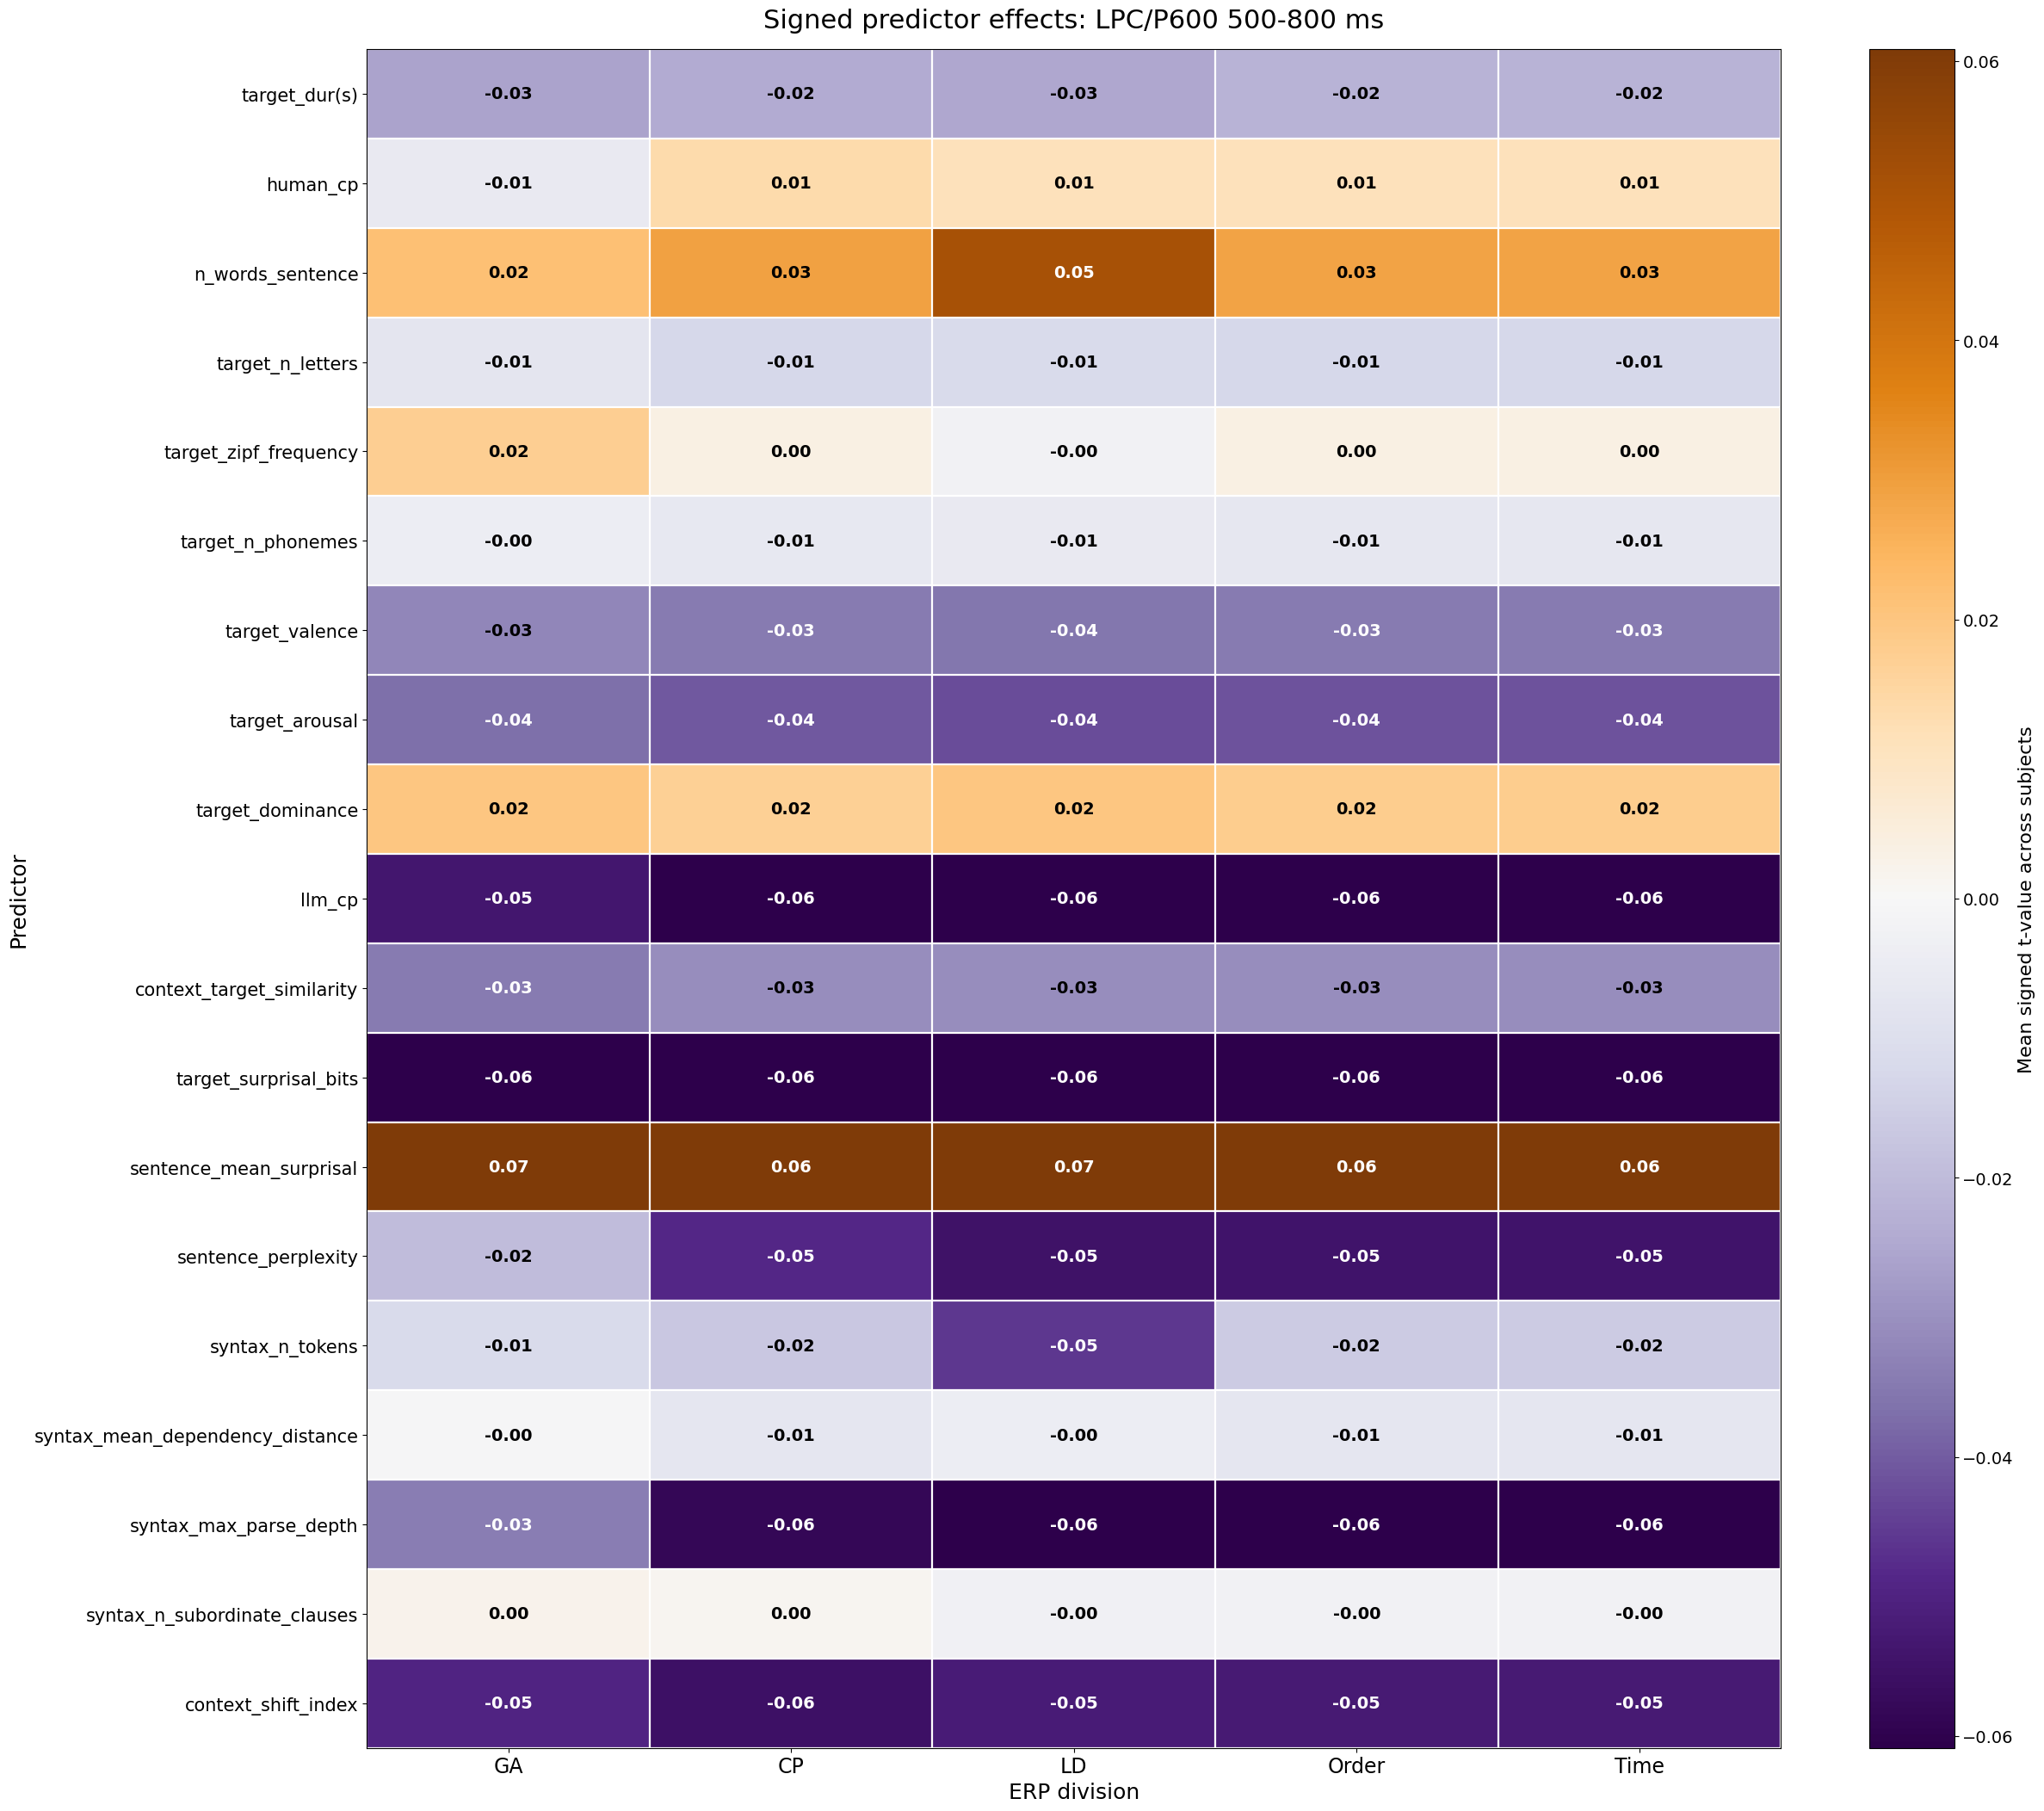

erp_division,predictor,GA,CP,LD,Order,Time
,target_dur(s),58.333333,65.0,60.0,65.0,65.0
,human_cp,54.166667,65.0,50.0,55.0,55.0
,n_words_sentence,54.166667,55.0,50.0,55.0,55.0
,target_n_letters,58.333333,60.0,60.0,60.0,60.0
,target_zipf_frequency,58.333333,50.0,55.0,55.0,55.0
,target_n_phonemes,54.166667,55.0,55.0,55.0,55.0
,target_valence,62.500000,80.0,70.0,70.0,70.0
,target_arousal,54.166667,55.0,50.0,55.0,55.0
,target_dominance,70.833333,75.0,75.0,75.0,75.0
,llm_cp,54.166667,55.0,55.0,55.0,55.0


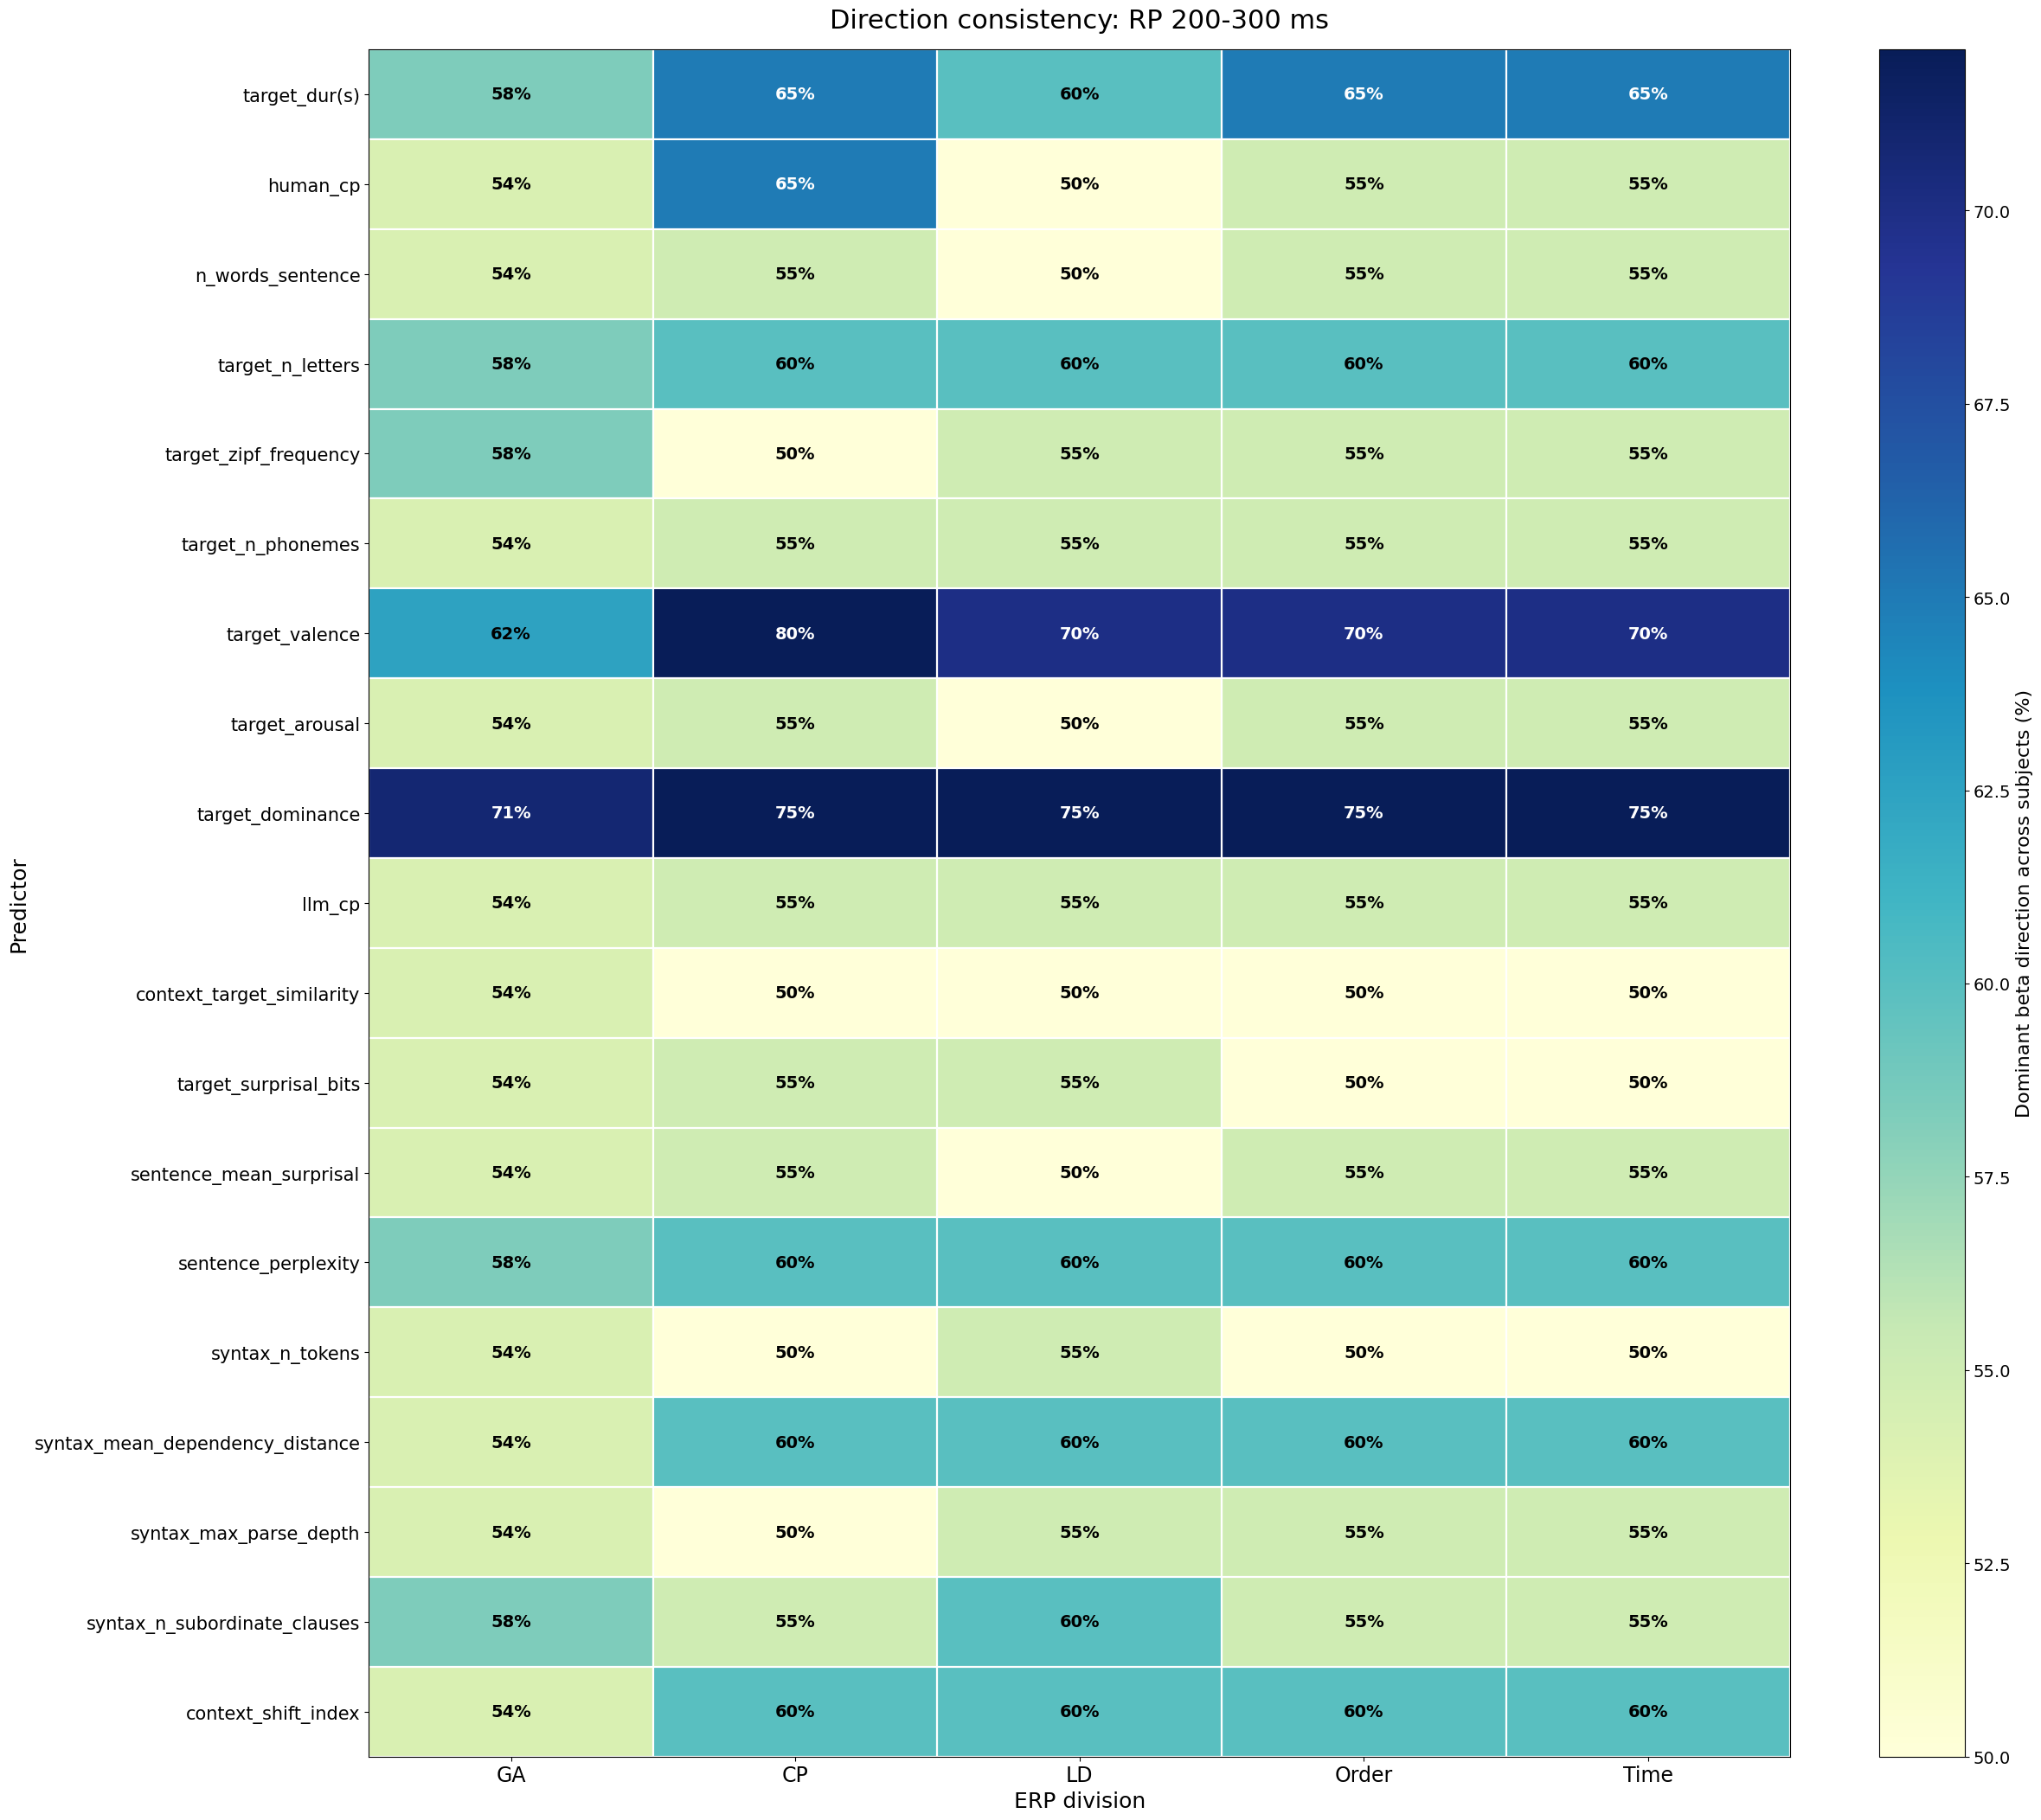

erp_division,predictor,GA,CP,LD,Order,Time
,target_dur(s),62.500000,60.0,65.0,60.0,60.0
,human_cp,58.333333,55.0,50.0,55.0,55.0
,n_words_sentence,62.500000,60.0,55.0,60.0,60.0
,target_n_letters,66.666667,65.0,65.0,70.0,70.0
,target_zipf_frequency,66.666667,70.0,70.0,70.0,70.0
,target_n_phonemes,50.000000,50.0,55.0,50.0,50.0
,target_valence,54.166667,65.0,60.0,55.0,55.0
,target_arousal,50.000000,55.0,55.0,50.0,50.0
,target_dominance,62.500000,60.0,55.0,60.0,60.0
,llm_cp,54.166667,50.0,50.0,50.0,50.0


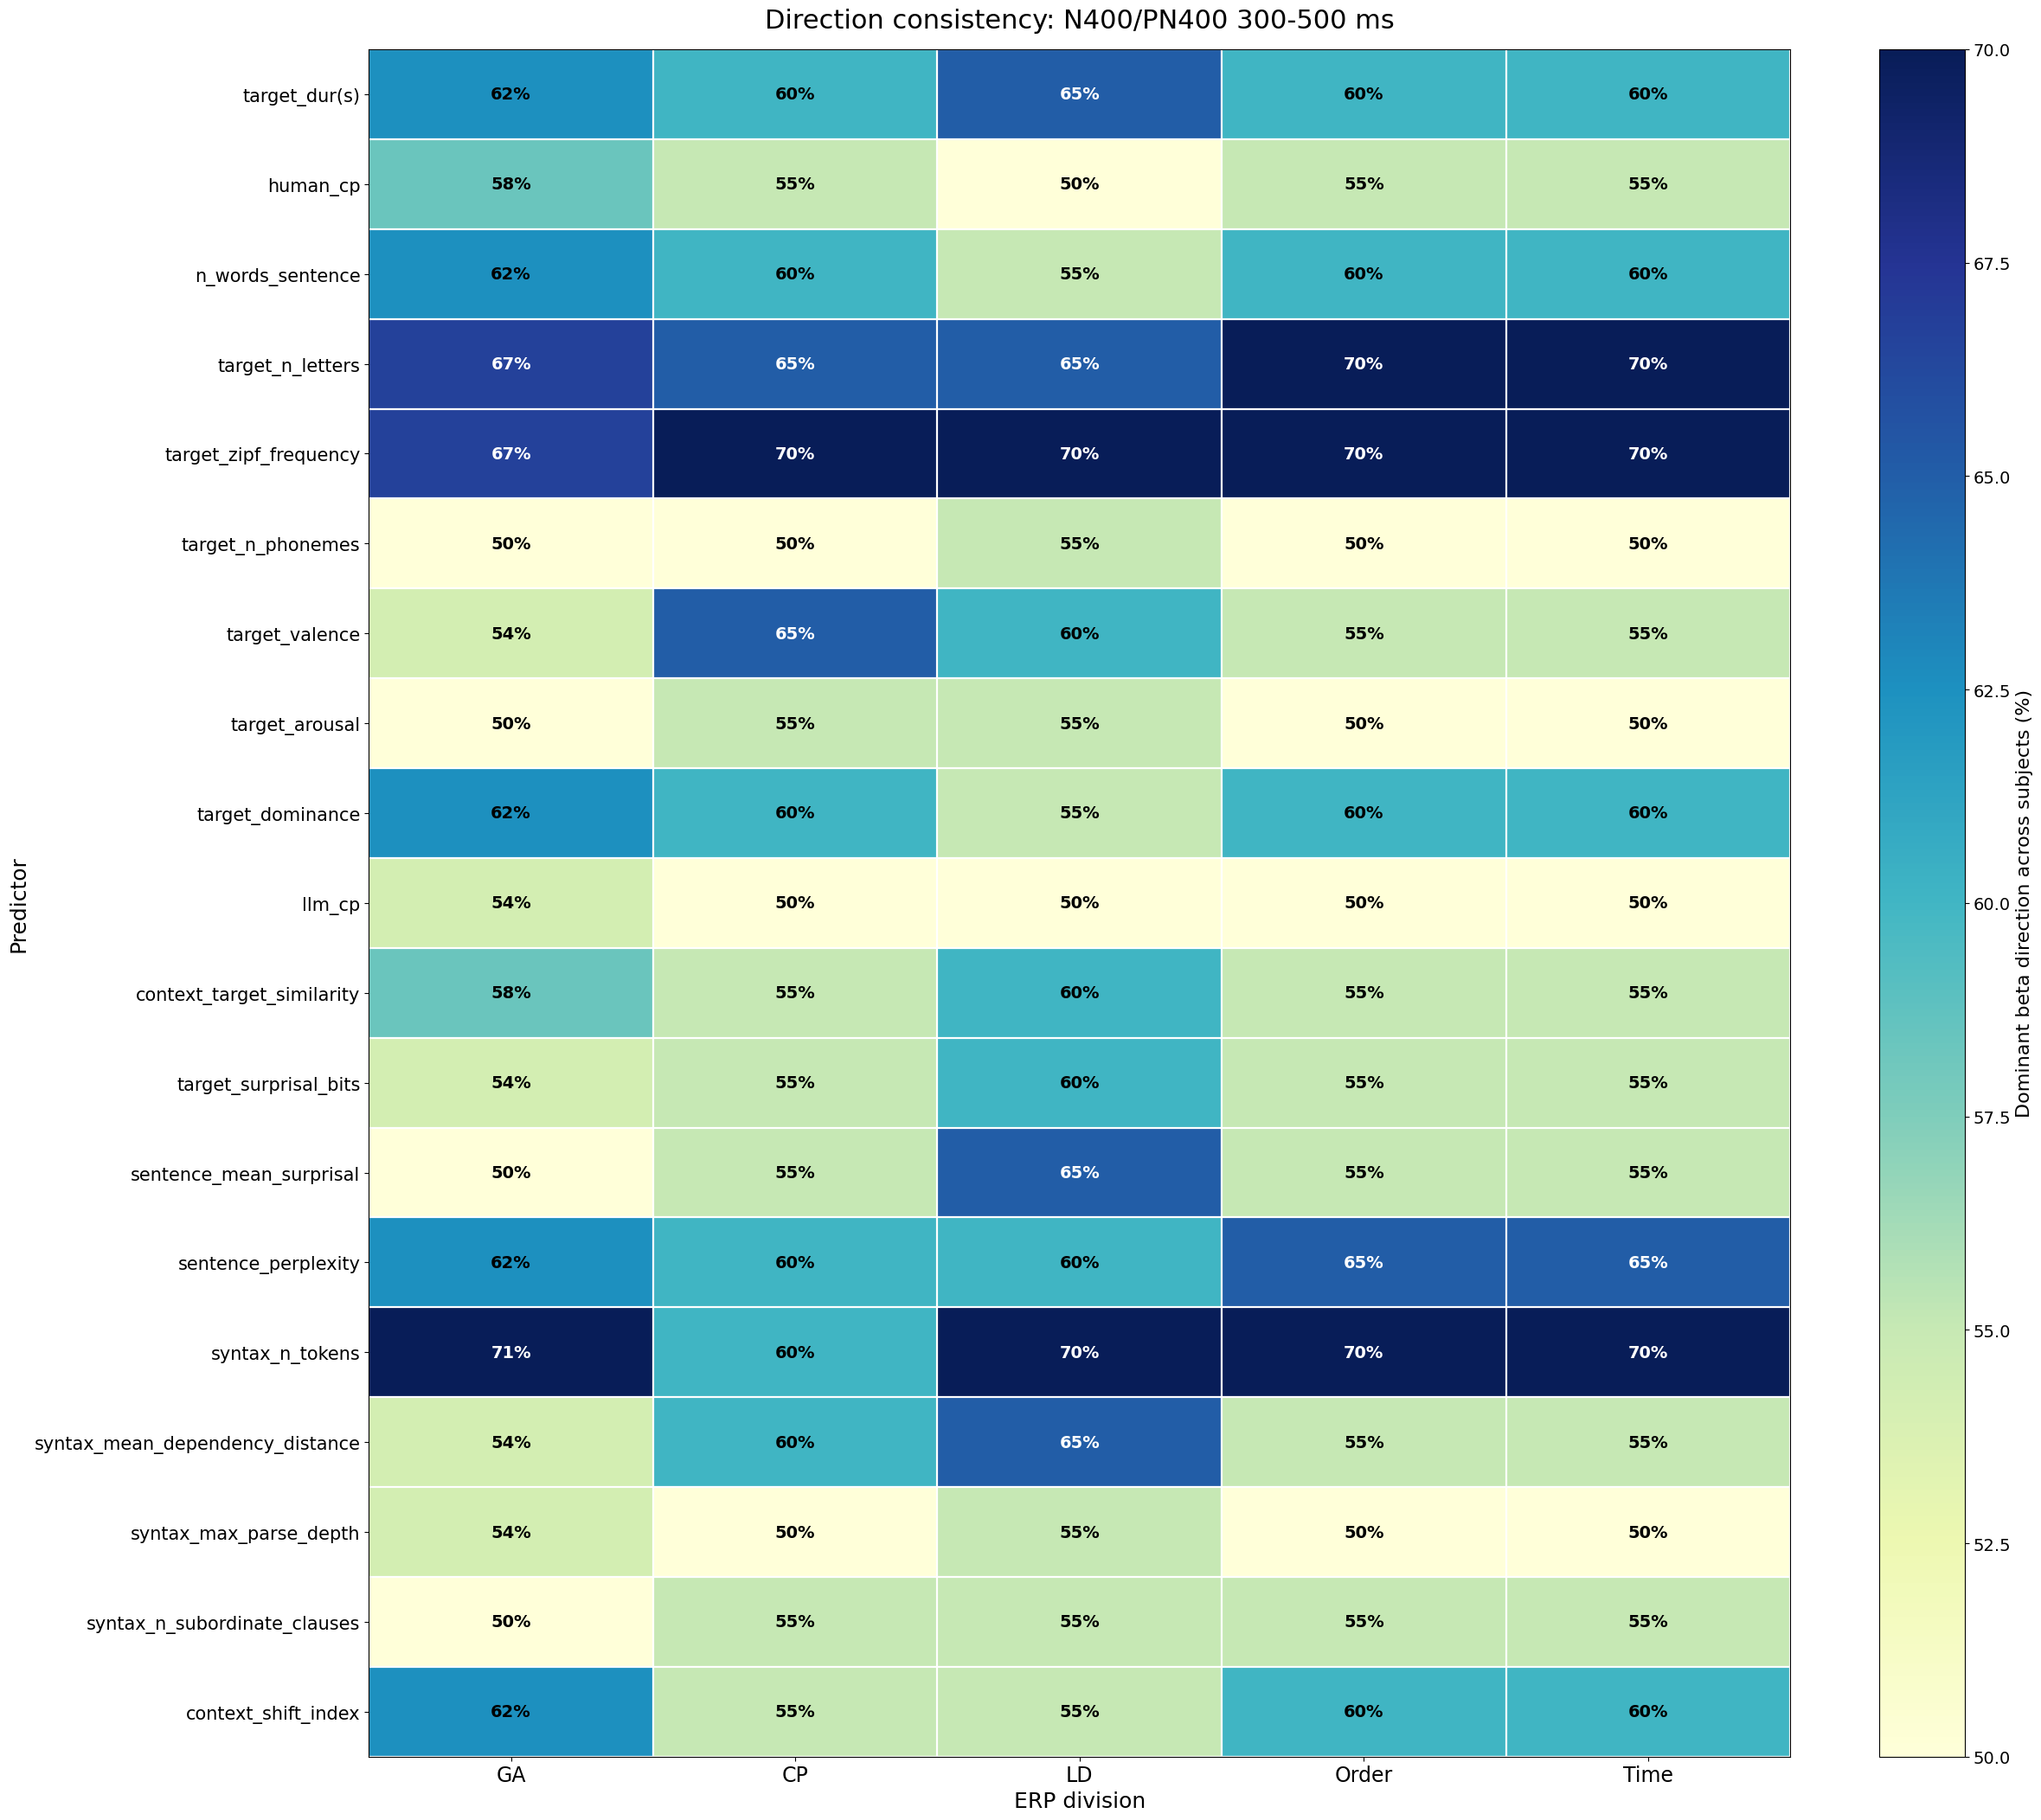

erp_division,predictor,GA,CP,LD,Order,Time
,target_dur(s),58.333333,55.0,60.0,55.0,55.0
,human_cp,58.333333,55.0,60.0,60.0,60.0
,n_words_sentence,58.333333,60.0,55.0,60.0,60.0
,target_n_letters,50.000000,50.0,50.0,55.0,55.0
,target_zipf_frequency,70.833333,75.0,75.0,75.0,75.0
,target_n_phonemes,50.000000,55.0,55.0,50.0,50.0
,target_valence,62.500000,60.0,65.0,65.0,65.0
,target_arousal,54.166667,55.0,55.0,60.0,60.0
,target_dominance,62.500000,60.0,60.0,60.0,60.0
,llm_cp,54.166667,60.0,65.0,60.0,60.0


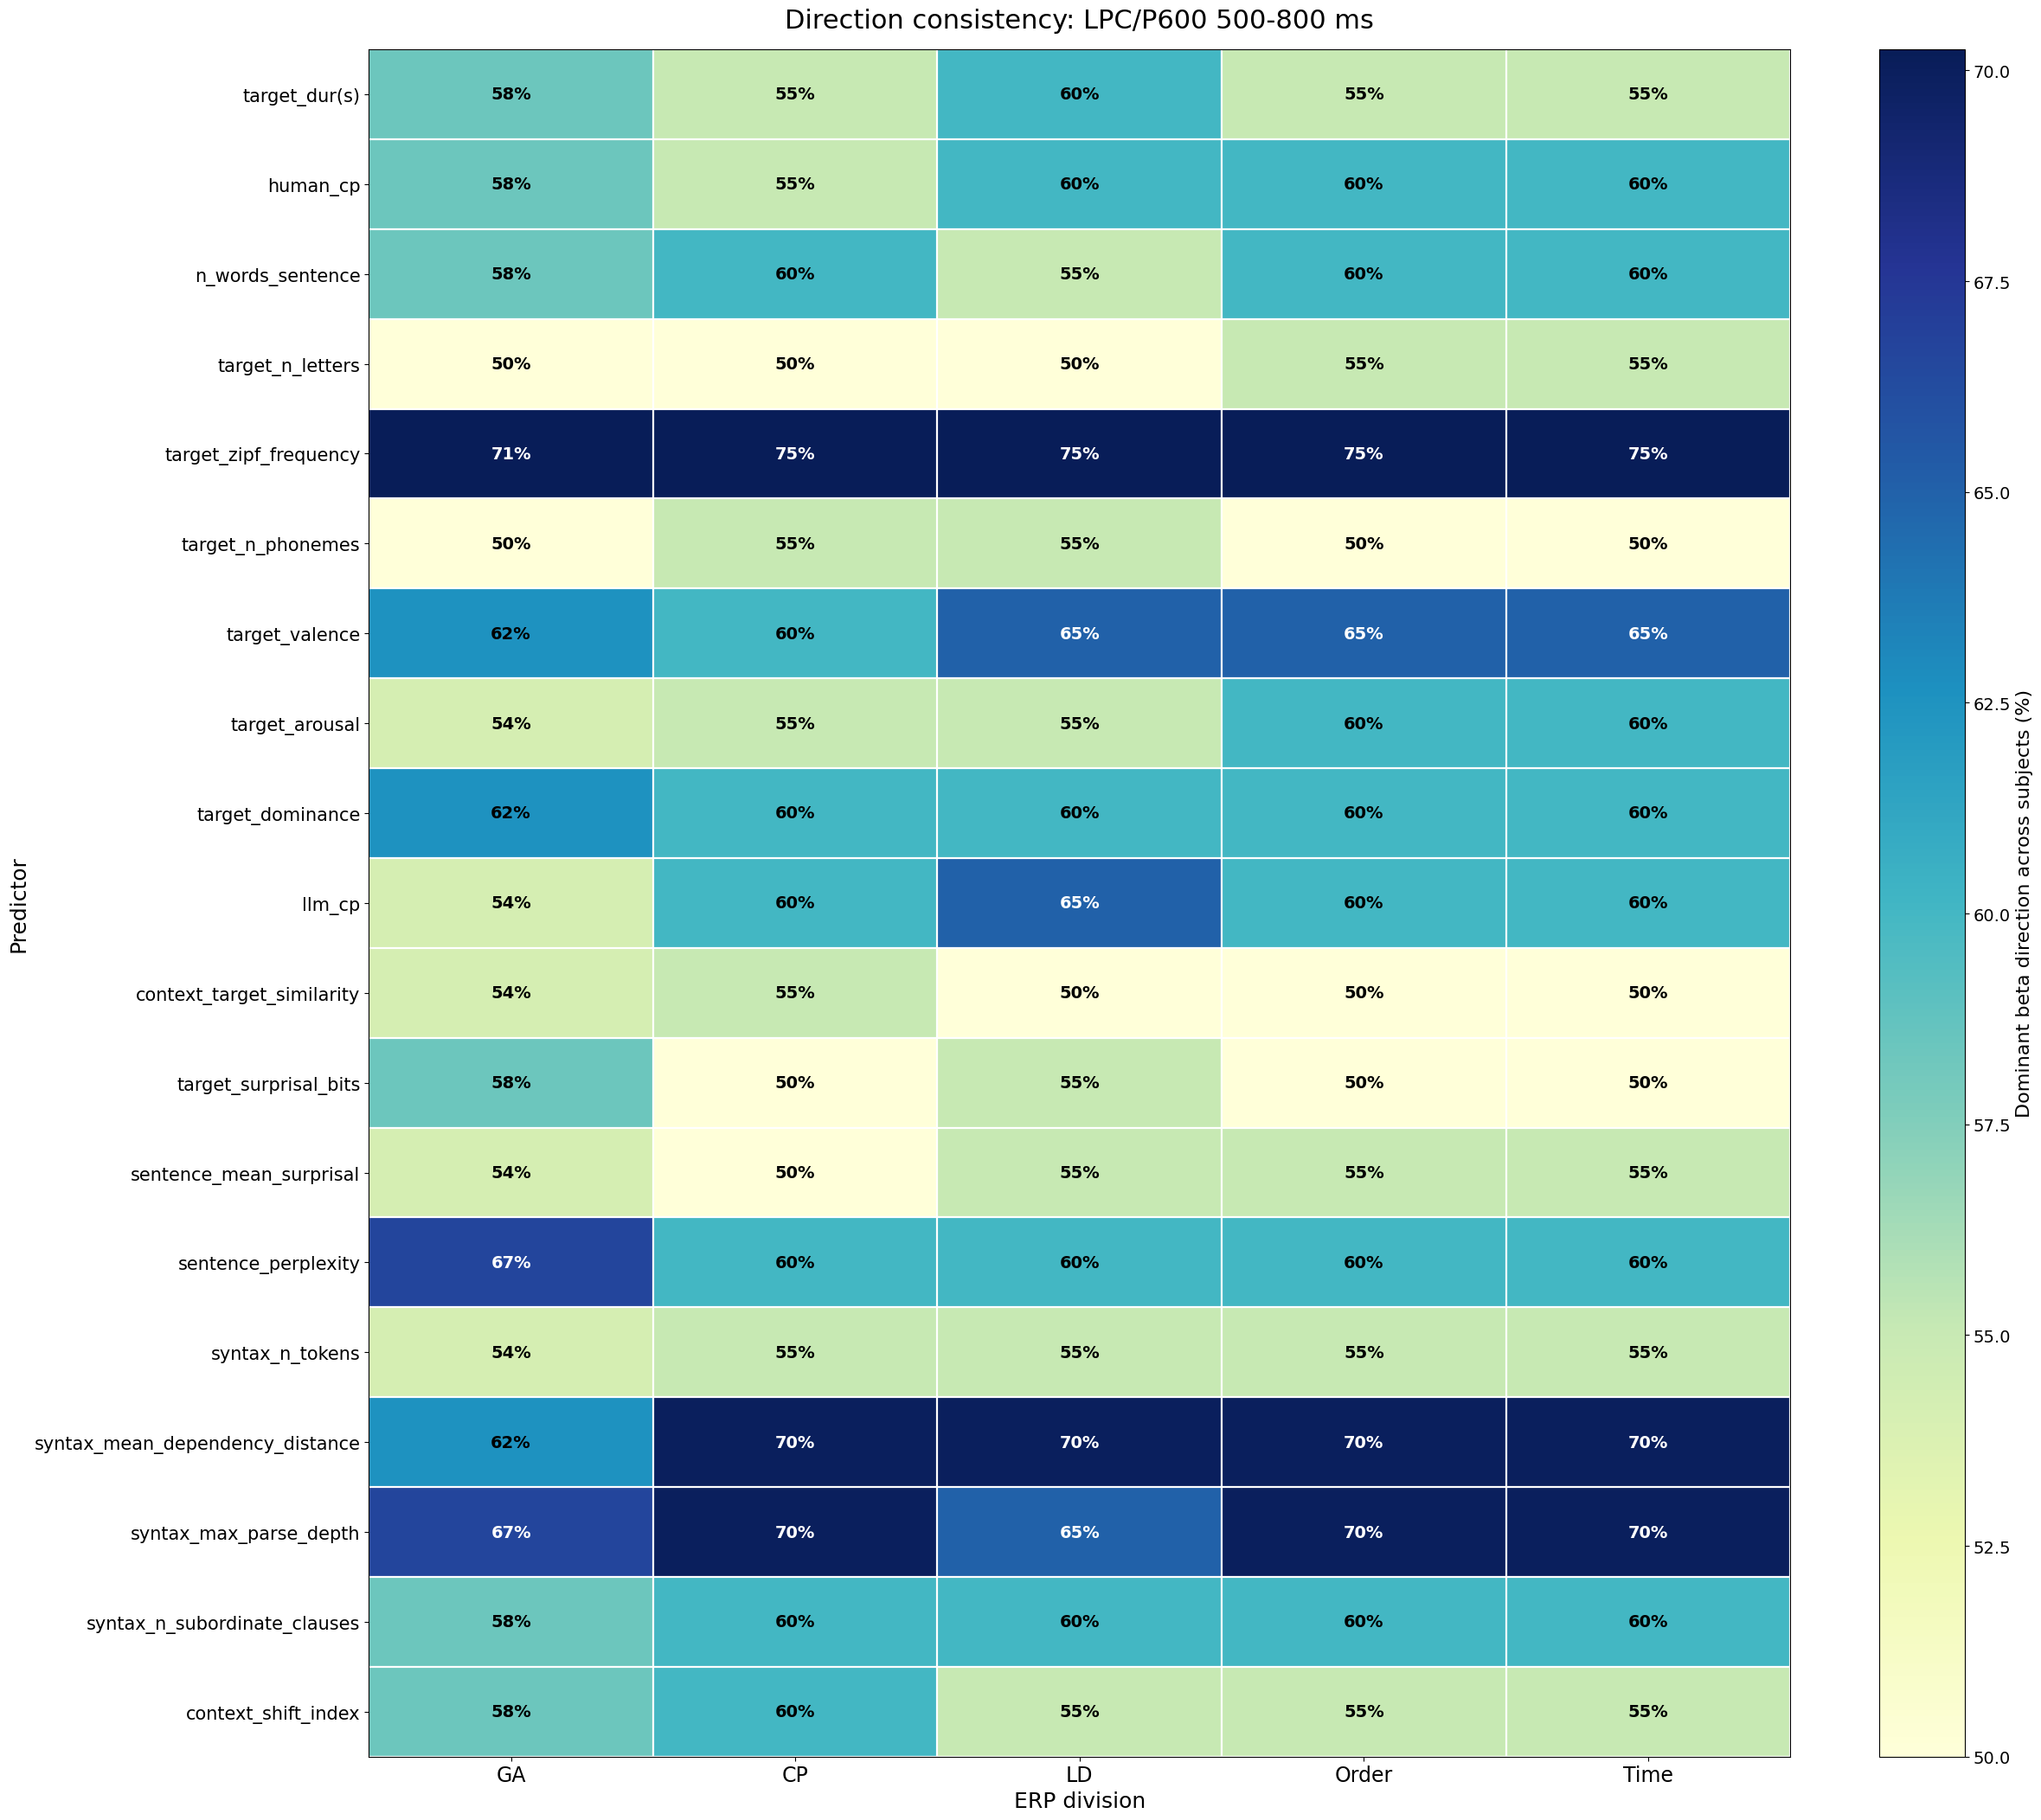

In [45]:
import json
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML

GLM_ROOT = Path("/content/Semantically_Incongruent_or_Congruent_Eggplants_revised/erp_glm_outputs")

TIME_WINDOWS = {
    "RP 200-300 ms": (200, 300),
    "N400/PN400 300-500 ms": (300, 500),
    "LPC/P600 500-800 ms": (500, 800),
}

ERP_DIVISION_MEANINGS = {
    "GA": "Grand average: congruent vs incongruent",
    "CP": "Cloze probability: congruent/incongruent trials separated by cloze-probability group",
    "LD": "Linguistic division: semantic-only errors vs combined semantic/syntactic errors",
    "Order": "Presentation order: whether the congruent or incongruent paired sentence was presented first",
    "Time": "Experiment time: trials separated by quarter of the experiment",
}

PREDICTOR_MEANINGS = {
    "target_dur(s)": "Duration of the spoken sentence-final target word in seconds. This captures acoustic exposure time and controls for differences in how long the auditory target was physically present.",
    "human_cp": "Human cloze probability for the target word. This is the proportion of human responses predicting the same target from the preceding context, so higher values indicate greater human expectancy.",
    "n_words_sentence": "Total number of words in the sentence. This captures sentence length and the amount of preceding linguistic context available before the final target word.",
    "target_n_letters": "Number of letters in the target word. This is a word-form length measure included as a lexical control.",
    "target_zipf_frequency": "Zipf-scale lexical frequency of the target word. Higher values indicate more frequent words, which are generally easier to access lexically.",
    "target_n_phonemes": "Number of phonemes in the spoken target word. This captures phonological length and controls for complexity of the auditory word form.",
    "target_valence": "Valence rating of the target word. Higher values indicate more positive or pleasant affective meaning.",
    "target_arousal": "Arousal rating of the target word. Higher values indicate more emotionally activating or intense word meaning.",
    "target_dominance": "Dominance rating of the target word. Higher values indicate stronger associations with control, power, or agency.",
    "llm_cp": "Language-model cloze probability for the target word given the preceding context. Higher values indicate that the model assigned higher contextual probability to the observed target.",
    "context_target_similarity": "Semantic similarity between the preceding sentence context and the target word. Higher values indicate stronger semantic fit between the context and the final word.",
    "target_surprisal_bits": "Information-theoretic surprisal of the target word in bits. Higher values indicate that the target was less predictable from the preceding context.",
    "sentence_mean_surprisal": "Mean surprisal across the sentence. This represents overall sentence-level unpredictability rather than only the final target-word expectancy.",
    "sentence_perplexity": "Perplexity of the full sentence under the language model. Higher values indicate lower overall model predictability for the sentence.",
    "syntax_n_tokens": "Number of tokens in the syntactic parse. This indexes sentence size in the syntactic representation.",
    "syntax_mean_dependency_distance": "Mean distance between syntactically linked words. Higher values indicate longer dependency relations and greater syntactic integration demands.",
    "syntax_max_parse_depth": "Maximum depth of the syntactic parse tree. Higher values indicate more deeply embedded syntactic structure.",
    "syntax_n_subordinate_clauses": "Number of subordinate clauses in the sentence. Higher values indicate greater clausal embedding and sentence-level syntactic complexity.",
    "context_shift_index": "Measure of semantic discontinuity between the preceding sentence context and the target word. Higher values indicate a stronger shift from the built-up context to the sentence-final word.",
}

def show_table(df, title=None, max_height="420px", wrap=True):
    if title is not None:
        display(HTML(f"""
        <h3 style="
            margin-top: 18px;
            margin-bottom: 8px;
            font-weight: bold;
        ">
            {title}
        </h3>
        """))

    html = df.to_html(index=False, escape=False)

    if wrap:
        td_style = """
            white-space: normal;
            word-break: normal;
            overflow-wrap: normal;
            max-width: 420px;
        """
    else:
        td_style = """
            white-space: nowrap;
            word-break: normal;
            overflow-wrap: normal;
            max-width: none;
        """

    display(HTML(f"""
    <div style="
        max-height: {max_height};
        overflow-y: auto;
        overflow-x: auto;
        border: 1px solid #999999;
        padding: 8px;
        font-size: 13px;
        margin-bottom: 18px;
        width: 100%;
    ">
        <style>
            table {{
                border-collapse: collapse;
                width: auto;
                min-width: 100%;
            }}

            th {{
                border: 1px solid #777777;
                padding: 7px;
                text-align: left;
                vertical-align: top;
                white-space: nowrap;
                background-color: #222222 !important;
                color: #ffffff !important;
                position: sticky;
                top: 0;
                z-index: 2;
                font-weight: bold;
            }}

            td {{
                border: 1px solid #dddddd;
                padding: 6px;
                text-align: left;
                vertical-align: top;
                {td_style}
            }}
        </style>
        {html}
    </div>
    """))

plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

def read_string_dataset(h5, name):
    values = h5[name][()]
    out = []

    for value in values:
        if isinstance(value, bytes):
            out.append(value.decode("utf-8"))
        else:
            out.append(str(value))

    return out

def load_result_file(path):
    with h5py.File(path, "r") as h5:
        metadata = json.loads(h5.attrs["metadata_json"])

        return {
            "path": path,
            "subject": metadata["subject"],
            "erp_division": metadata["analysis"],
            "metadata": metadata,
            "beta": h5["beta"][()],
            "t": h5["t"][()],
            "times": h5["times"][()],
            "predictor_names": read_string_dataset(h5, "predictor_names"),
            "channel_names": read_string_dataset(h5, "channel_names"),
            "rank": int(h5.attrs["rank"]),
            "dof": int(h5.attrs["dof"]),
        }

h5_paths = sorted(GLM_ROOT.rglob("erp_glm_results.h5"))

if len(h5_paths) == 0:
    raise FileNotFoundError(f"No erp_glm_results.h5 files found under {GLM_ROOT}")

models = [load_result_file(path) for path in h5_paths]

predictors = []

for model in models:
    for predictor in model["predictor_names"]:
        if predictor != "intercept" and predictor not in predictors:
            predictors.append(predictor)

available_divisions = {model["erp_division"] for model in models}
erp_divisions = [division for division in ["GA", "CP", "LD", "Order", "Time"] if division in available_divisions]
subjects = sorted({model["subject"] for model in models})

display(HTML(f"""
<h2 style="font-weight: bold; margin-bottom: 16px;">
ERP GLM predictor-effect summary
</h2>

<p>
The fitted ERP GLMs were summarised across subjects, ERP divisions, and predefined ERP time windows.
Each subject-level model produced beta and t-value maps for each linguistic predictor across electrodes and timepoints.
</p>

<p>
The analysis included <b>{len(models)}</b> fitted models, <b>{len(subjects)}</b> subjects,
<b>{len(erp_divisions)}</b> ERP divisions, and <b>{len(predictors)}</b> predictors.
</p>

<p>
The ERP divisions were GA, CP, LD, Order, and Time. GA corresponds to the main congruent-incongruent
grand-average division, CP to the cloze-probability division, LD to the linguistic-error division,
Order to the presentation-order division, and Time to the experiment-time division.
</p>

<p>
For each subject, predictor, ERP division, and time window, the beta and t-value maps were summarised
within the RP, N400/PN400, and LPC/P600 ranges. Positive beta values indicate that higher predictor
values were associated with more positive ERP amplitudes, whereas negative beta values indicate
association with more negative ERP amplitudes. Signed t-values summarise the direction and relative
strength of the fitted association, while absolute t-values identify the strongest local electrode-time
associations within each window.
</p>
"""))

overview_table = pd.DataFrame(
    [
        {"measure": "fitted_models", "value": len(models)},
        {"measure": "subjects", "value": len(subjects)},
        {"measure": "erp_divisions", "value": len(erp_divisions)},
        {"measure": "predictors", "value": len(predictors)},
    ]
)

show_table(overview_table, title="Overview", max_height="220px", wrap=False)

division_table = pd.DataFrame(
    [
        {
            "erp_division": division,
            "description": ERP_DIVISION_MEANINGS[division],
        }
        for division in erp_divisions
    ]
)

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
ERP divisions
</h3>
<p style="margin-top: 0;">
The fitted models are summarised separately for the five preprocessed ERP divisions provided with the N400Stimset derivatives.
</p>
"""))

show_table(division_table, max_height="260px", wrap=True)

predictor_table = pd.DataFrame(
    [
        {
            "predictor": predictor,
            "description": PREDICTOR_MEANINGS.get(predictor, ""),
        }
        for predictor in predictors
    ]
)

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
Linguistic predictors
</h3>
<p style="margin-top: 0;">
The predictors represent trial-level acoustic, lexical, semantic, syntactic, affective, and expectancy-related properties of the sentence-final target word and its preceding sentence context.
</p>
"""))

show_table(predictor_table, max_height="520px", wrap=True)

model_table = pd.DataFrame(
    [
        {
            "subject": model["subject"],
            "erp_division": model["erp_division"],
            "n_trials_used": model["metadata"]["n_epochs_used"],
            "n_channels": model["metadata"]["n_channels"],
            "n_timepoints": model["metadata"]["n_times"],
            "n_predictors_including_intercept": model["metadata"]["n_predictors_including_intercept"],
            "rank": model["rank"],
            "degrees_of_freedom": model["dof"],
        }
        for model in models
    ]
)

model_summary_table = (
    model_table
    .groupby("erp_division", as_index=False)
    .agg(
        n_models=("subject", "count"),
        n_subjects=("subject", "nunique"),
        mean_trials_used=("n_trials_used", "mean"),
        min_trials_used=("n_trials_used", "min"),
        max_trials_used=("n_trials_used", "max"),
        n_channels=("n_channels", "median"),
        n_timepoints=("n_timepoints", "median"),
        n_predictors_including_intercept=("n_predictors_including_intercept", "median"),
        min_rank=("rank", "min"),
        max_rank=("rank", "max"),
        min_degrees_of_freedom=("degrees_of_freedom", "min"),
        max_degrees_of_freedom=("degrees_of_freedom", "max"),
    )
)

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
Fitted models
</h3>
<p style="margin-top: 0;">
The fitted-model summary reports the number of subject-level models per ERP division, retained-trial counts, electrode and timepoint counts, model rank, and residual degrees of freedom.
</p>
"""))

show_table(model_summary_table, max_height="300px", wrap=False)

rows = []

for model in models:
    beta = model["beta"]
    t_values = model["t"]
    times = model["times"]
    predictor_names = model["predictor_names"]
    channel_names = model["channel_names"]

    for predictor in predictors:
        if predictor not in predictor_names:
            continue

        predictor_index = predictor_names.index(predictor)

        for window_name, (start_ms, end_ms) in TIME_WINDOWS.items():
            time_mask = (times >= start_ms) & (times <= end_ms)

            if not np.any(time_mask):
                continue

            beta_window = beta[predictor_index, :, :][:, time_mask]
            t_window = t_values[predictor_index, :, :][:, time_mask]
            abs_t_window = np.abs(t_window)

            peak_flat_index = int(np.nanargmax(abs_t_window))
            peak_channel_index, peak_time_index = np.unravel_index(
                peak_flat_index,
                abs_t_window.shape,
            )

            rows.append(
                {
                    "subject": model["subject"],
                    "erp_division": model["erp_division"],
                    "predictor": predictor,
                    "erp_window": window_name,
                    "mean_beta": float(np.nanmean(beta_window)),
                    "mean_t": float(np.nanmean(t_window)),
                    "mean_abs_t": float(np.nanmean(abs_t_window)),
                    "peak_beta": float(beta_window[peak_channel_index, peak_time_index]),
                    "peak_t": float(t_window[peak_channel_index, peak_time_index]),
                    "peak_abs_t": float(abs_t_window[peak_channel_index, peak_time_index]),
                    "peak_time_ms": float(times[time_mask][peak_time_index]),
                    "peak_channel": str(channel_names[peak_channel_index]),
                }
            )

subject_effect_table = pd.DataFrame(rows)

if subject_effect_table.empty:
    raise ValueError("No ERP-window summaries were created. Check whether the time vector contains 200-800 ms values.")

summary_table = (
    subject_effect_table
    .groupby(
        [
            "erp_division",
            "predictor",
            "erp_window",
        ],
        as_index=False,
    )
    .agg(
        n_subjects=("subject", "nunique"),
        mean_beta_across_subjects=("mean_beta", "mean"),
        mean_t_across_subjects=("mean_t", "mean"),
        mean_abs_t_across_subjects=("mean_abs_t", "mean"),
        mean_peak_abs_t_across_subjects=("peak_abs_t", "mean"),
        median_peak_time_ms=("peak_time_ms", "median"),
        n_beta_positive=("mean_beta", lambda x: int((x > 0).sum())),
        n_beta_negative=("mean_beta", lambda x: int((x < 0).sum())),
    )
)

summary_table["percent_beta_positive"] = 100 * summary_table["n_beta_positive"] / summary_table["n_subjects"]
summary_table["percent_beta_negative"] = 100 * summary_table["n_beta_negative"] / summary_table["n_subjects"]

summary_table["dominant_direction"] = np.where(
    summary_table["percent_beta_positive"] > summary_table["percent_beta_negative"],
    "positive",
    np.where(
        summary_table["percent_beta_negative"] > summary_table["percent_beta_positive"],
        "negative",
        "mixed",
    ),
)

summary_table["direction_consistency_percent"] = summary_table[
    ["percent_beta_positive", "percent_beta_negative"]
].max(axis=1)

summary_table_display = (
    summary_table
    .sort_values(["erp_window", "mean_peak_abs_t_across_subjects"], ascending=[True, False])
    .reset_index(drop=True)
)

display(HTML(f"""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
Group-level ERP-window summaries
</h3>
<p style="margin-top: 0;">
The group summary table contains <b>{len(summary_table)}</b> rows. Each row corresponds to one ERP division,
one predictor, and one ERP time window after averaging subject-level summaries across participants.
Direction consistency is the percentage of subjects showing the dominant beta direction for that predictor,
division, and window.
</p>
"""))

show_table(summary_table_display, max_height="520px", wrap=False)

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
Strongest local predictor-ERP associations
</h3>
<p style="margin-top: 0;">
Predictor-window combinations ranked by the mean strongest local absolute t-value across subjects.
Values summarise the largest electrode-time association observed within each ERP window and division.
</p>
"""))

top_effects = (
    summary_table
    .sort_values("mean_peak_abs_t_across_subjects", ascending=False)
    .head(30)
    .copy()
)

top_effects["label"] = (
    top_effects["erp_window"]
    + " | "
    + top_effects["erp_division"]
    + " | "
    + top_effects["predictor"]
)

show_table(top_effects, max_height="420px", wrap=False)

plot_values = top_effects["mean_peak_abs_t_across_subjects"].to_numpy(dtype=float)
x_min = max(0, np.nanmin(plot_values) - 0.03)
x_max = np.nanmax(plot_values) + 0.03

fig, ax = plt.subplots(figsize=(18, 12))

ax.barh(
    top_effects["label"][::-1],
    top_effects["mean_peak_abs_t_across_subjects"][::-1],
    color="#4C72B0",
)

ax.set_xlim(x_min, x_max)
ax.set_xlabel("Mean strongest local absolute t-value across subjects", fontsize=18)
ax.set_ylabel("ERP window | ERP division | predictor", fontsize=18)
ax.set_title("Strongest local predictor-ERP associations", fontsize=22, pad=18)
ax.tick_params(axis="x", labelsize=15)
ax.tick_params(axis="y", labelsize=14)

for index, value in enumerate(top_effects["mean_peak_abs_t_across_subjects"][::-1]):
    ax.text(
        value,
        index,
        f" {value:.2f}",
        va="center",
        fontsize=14,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
Signed predictor effects by ERP window
</h3>
<p style="margin-top: 0;">
Average signed t-values for each predictor across the GA, CP, LD, Order, and Time ERP divisions.
Negative values indicate associations with more negative ERP amplitudes; positive values indicate
associations with more positive ERP amplitudes. The colour scale is centred on zero and uses percentile
scaling to increase contrast among the observed values.
</p>
<p>
The RP window indexes earlier activity, the N400/PN400 window indexes the main semantic expectancy
and integration range, and the LPC/P600 window indexes later or sustained processing.
</p>
"""))

for window_name in TIME_WINDOWS.keys():
    window_summary = summary_table[summary_table["erp_window"] == window_name].copy()

    signed_matrix = (
        window_summary
        .pivot_table(
            index="predictor",
            columns="erp_division",
            values="mean_t_across_subjects",
            aggfunc="mean",
        )
        .reindex(index=predictors, columns=erp_divisions)
    )

    values = signed_matrix.to_numpy(dtype=float)

    if np.all(np.isnan(values)):
        continue

    finite_values = values[np.isfinite(values)]
    vmax = np.percentile(np.abs(finite_values), 85)

    if not np.isfinite(vmax) or vmax == 0:
        vmax = np.nanmax(np.abs(finite_values))

    if not np.isfinite(vmax) or vmax == 0:
        vmax = 1

    display(HTML(f"""
    <h4 style="margin-top: 18px; margin-bottom: 8px; font-weight: bold;">
    {window_name}
    </h4>
    """))

    show_table(signed_matrix.reset_index(), max_height="420px", wrap=False)

    fig, ax = plt.subplots(figsize=(3.4 * len(erp_divisions) + 8, 0.85 * len(predictors) + 5))

    image = ax.imshow(
        values,
        aspect="auto",
        vmin=-vmax,
        vmax=vmax,
        cmap="PuOr_r",
    )

    cbar = fig.colorbar(image, ax=ax)
    cbar.set_label("Mean signed t-value across subjects", fontsize=16)
    cbar.ax.tick_params(labelsize=14)

    ax.set_xticks(range(len(erp_divisions)))
    ax.set_xticklabels(erp_divisions, fontsize=17)

    ax.set_yticks(range(len(predictors)))
    ax.set_yticklabels(predictors, fontsize=15)

    ax.set_xlabel("ERP division", fontsize=18)
    ax.set_ylabel("Predictor", fontsize=18)
    ax.set_title(f"Signed predictor effects: {window_name}", fontsize=22, pad=18)

    threshold = 0.55 * vmax

    for row_index in range(values.shape[0]):
        for col_index in range(values.shape[1]):
            value = values[row_index, col_index]
            if np.isfinite(value):
                text_color = "white" if abs(value) >= threshold else "black"
                ax.text(
                    col_index,
                    row_index,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=14,
                    color=text_color,
                    fontweight="bold",
                )

    ax.set_xticks(np.arange(-0.5, len(erp_divisions), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(predictors), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    plt.show()

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
Direction consistency across subjects
</h3>
<p style="margin-top: 0;">
Percentage of subjects showing the dominant beta direction for each predictor, ERP division, and ERP window.
Higher values indicate more stable direction of association across participants.
</p>
"""))

for window_name in TIME_WINDOWS.keys():
    window_summary = summary_table[summary_table["erp_window"] == window_name].copy()

    consistency_matrix = (
        window_summary
        .pivot_table(
            index="predictor",
            columns="erp_division",
            values="direction_consistency_percent",
            aggfunc="mean",
        )
        .reindex(index=predictors, columns=erp_divisions)
    )

    values = consistency_matrix.to_numpy(dtype=float)

    if np.all(np.isnan(values)):
        continue

    finite_values = values[np.isfinite(values)]
    vmin = max(50, np.nanpercentile(finite_values, 5))
    vmax = min(100, np.nanpercentile(finite_values, 95))

    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin = 50
        vmax = 100

    display(HTML(f"""
    <h4 style="margin-top: 18px; margin-bottom: 8px; font-weight: bold;">
    {window_name}
    </h4>
    """))

    show_table(consistency_matrix.reset_index(), max_height="420px", wrap=False)

    fig, ax = plt.subplots(figsize=(3.4 * len(erp_divisions) + 8, 0.85 * len(predictors) + 5))

    image = ax.imshow(
        values,
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        cmap="YlGnBu",
    )

    cbar = fig.colorbar(image, ax=ax)
    cbar.set_label("Dominant beta direction across subjects (%)", fontsize=16)
    cbar.ax.tick_params(labelsize=14)

    ax.set_xticks(range(len(erp_divisions)))
    ax.set_xticklabels(erp_divisions, fontsize=17)

    ax.set_yticks(range(len(predictors)))
    ax.set_yticklabels(predictors, fontsize=15)

    ax.set_xlabel("ERP division", fontsize=18)
    ax.set_ylabel("Predictor", fontsize=18)
    ax.set_title(f"Direction consistency: {window_name}", fontsize=22, pad=18)

    threshold = vmin + 0.65 * (vmax - vmin)

    for row_index in range(values.shape[0]):
        for col_index in range(values.shape[1]):
            value = values[row_index, col_index]
            if np.isfinite(value):
                text_color = "white" if value >= threshold else "black"
                ax.text(
                    col_index,
                    row_index,
                    f"{value:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=14,
                    color=text_color,
                    fontweight="bold",
                )

    ax.set_xticks(np.arange(-0.5, len(erp_divisions), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(predictors), 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    plt.show()

display(HTML("""
<h3 style="margin-top: 24px; margin-bottom: 8px; font-weight: bold;">
Interpretation of the fitted predictor effects
</h3>
<p>
The fitted effects describe how sentence-final linguistic predictors relate to ERP amplitude across the
N400Stimset ERP divisions and time windows. Effects in the RP range correspond to earlier activity,
effects in the N400/PN400 range correspond to semantic expectancy and integration, and effects in the
LPC/P600 range correspond to later or sustained processing. The clearest patterns are those combining
stronger local t-values, a stable signed direction, and high direction consistency across subjects.
</p>
"""))